# MADIS Data Exploration and Cleaning

This notebook explores the downloaded MADIS Personal Weather Station data, cleans up any issues, checks for outliers, and prepares the data for use in the CNN model.

## Steps:
1. Load and inspect MADIS XML files
2. Identify and clean blank/corrupted files
3. Extract features from valid files
4. Check for outliers and data quality
5. Merge with TorNet catalog
6. Analyze coverage by storm type
7. **Temporal alignment analysis**
8. **Spatial coverage analysis**
9. **Meteorological predictive power analysis**
   - 9.1 **Extreme value capture analysis**
   - 9.2 **Inter-feature correlation analysis**
   - 9.3 **Derived feature engineering** (NEW)
10. Prepare data for CNN integration
11. Save cleaned dataset
12. Next steps for CNN integration

## 1. Setup and Imports

In [2]:
import os
import sys
import shutil
from pathlib import Path
import xml.etree.ElementTree as ET
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
data_root = Path('/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data')
madis_dir = data_root / 'madis_data'
catalog_path = data_root / 'catalog.csv'

print(f"MADIS directory: {madis_dir}")
print(f"Directory exists: {madis_dir.exists()}")

MADIS directory: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/madis_data
Directory exists: True


## 2. Load and Inspect MADIS Files

In [3]:
# Get all XML files
xml_files = list(madis_dir.glob('*.xml'))
print(f"Total MADIS XML files found: {len(xml_files)}")

# Parse filename to extract storm_id and timestamp
def parse_madis_filename(filename):
    """
    Parse MADIS filename to extract storm ID and timestamp.
    Expected format: madis_data_{storm_id}_{timestamp}.xml
    """
    try:
        parts = filename.stem.split('_')
        if len(parts) >= 4 and parts[0] == 'madis' and parts[1] == 'data':
            storm_id = parts[2]
            timestamp = parts[3]
            return {'storm_id': storm_id, 'timestamp': timestamp, 'filename': filename.name}
        else:
            return {'storm_id': None, 'timestamp': None, 'filename': filename.name, 'error': 'Invalid format'}
    except Exception as e:
        return {'storm_id': None, 'timestamp': None, 'filename': filename.name, 'error': str(e)}

# Check filenames
print("\nChecking filename formats...")
filename_info = [parse_madis_filename(f) for f in xml_files[:10]]
pd.DataFrame(filename_info)

Total MADIS XML files found: 4483

Checking filename formats...


,storm_id,timestamp,filename
0,478457,2013-09-12 02:10:00,madis_data_478457_2013-09-12 02:10:00.xml
1,468392,2013-09-12 18:59:00,madis_data_468392_2013-09-12 18:59:00.xml
2,569142,2015-04-03 20:26:30,madis_data_569142_2015-04-03 20:26:30.xml
3,532412,2014-07-21 00:40:00,madis_data_532412_2014-07-21 00:40:00.xml
4,476567,2013-09-18 01:12:00,madis_data_476567_2013-09-18 01:12:00.xml
5,505632,2014-03-16 14:26:00,madis_data_505632_2014-03-16 14:26:00.xml
6,1073443,2013-12-14 22:07:30,madis_data_1073443_2013-12-14 22:07:30.xml
7,1073311,2013-09-21 11:54:00,madis_data_1073311_2013-09-21 11:54:00.xml
8,468386,2013-09-12 19:24:00,madis_data_468386_2013-09-12 19:24:00.xml
9,477106,2013-11-01 00:50:00,madis_data_477106_2013-11-01 00:50:00.xml


## 3. Identify Blank and Corrupted Files

In [4]:
# Analyze all MADIS files
def analyze_madis_file(xml_file):
    """
    Analyze a single MADIS XML file.
    Returns dict with file info and status.
    """
    result = {
        'filename': xml_file.name,
        'file_size': xml_file.stat().st_size,
        'is_valid': False,
        'has_data': False,
        'num_records': 0,
        'error': None
    }
    
    # Parse filename
    parsed = parse_madis_filename(xml_file)
    result['storm_id'] = parsed.get('storm_id')
    result['timestamp'] = parsed.get('timestamp')
    
    # Check if file is too small (likely empty or malformed)
    if result['file_size'] < 100:  # XML header alone is ~50-100 bytes
        result['error'] = 'File too small'
        return result
    
    # Try to parse XML
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        result['is_valid'] = True
        
        # Count records
        records = root.findall('.//record')
        result['num_records'] = len(records)
        result['has_data'] = len(records) > 0
        
        # Extract some stats if has data
        if result['has_data']:
            # Get unique variables
            variables = set(r.attrib.get('var') for r in records)
            result['variables'] = ', '.join(sorted(variables))
            result['num_variables'] = len(variables)
            
            # Get unique stations
            stations = set(r.attrib.get('shef_id') for r in records if r.attrib.get('shef_id'))
            result['num_stations'] = len(stations)
        
    except ET.ParseError as e:
        result['error'] = f'XML parse error: {str(e)[:50]}'
    except Exception as e:
        result['error'] = f'Error: {str(e)[:50]}'
    
    return result

# Analyze all files
print("Analyzing all MADIS files...")
print("This may take a few minutes...\n")

file_analysis = []
for xml_file in tqdm(xml_files, desc="Processing files"):
    analysis = analyze_madis_file(xml_file)
    file_analysis.append(analysis)

# Convert to DataFrame
df_files = pd.DataFrame(file_analysis)

# Display summary
print("\n" + "="*70)
print("FILE ANALYSIS SUMMARY")
print("="*70)
print(f"Total files:              {len(df_files)}")
print(f"Valid XML files:          {df_files['is_valid'].sum()}")
print(f"Files with data:          {df_files['has_data'].sum()}")
print(f"Empty files (no records): {(df_files['is_valid'] & ~df_files['has_data']).sum()}")
print(f"Corrupted/Invalid files:  {(~df_files['is_valid']).sum()}")
print(f"\nTotal weather records:    {df_files['num_records'].sum()}")

# Show files with issues
problematic = df_files[~df_files['is_valid'] | ~df_files['has_data']]
if len(problematic) > 0:
    print(f"\nProblematic files: {len(problematic)}")
    print("\nFirst 10 problematic files:")
    print(problematic[['filename', 'file_size', 'is_valid', 'has_data', 'error']].head(10))

df_files.head()

Analyzing all MADIS files...
This may take a few minutes...



Processing files: 100%|██████████| 4483/4483 [00:06<00:00, 651.16it/s]


FILE ANALYSIS SUMMARY
Total files:              4483
Valid XML files:          2026
Files with data:          2026
Empty files (no records): 0
Corrupted/Invalid files:  2457

Total weather records:    28880

Problematic files: 2457

First 10 problematic files:
                                      filename  file_size  is_valid  has_data  \
1    madis_data_468392_2013-09-12 18:59:00.xml         43     False     False   
3    madis_data_532412_2014-07-21 00:40:00.xml         43     False     False   
4    madis_data_476567_2013-09-18 01:12:00.xml         43     False     False   
5    madis_data_505632_2014-03-16 14:26:00.xml         43     False     False   
6   madis_data_1073443_2013-12-14 22:07:30.xml         43     False     False   
8    madis_data_468386_2013-09-12 19:24:00.xml         43     False     False   
10   madis_data_532893_2014-08-24 02:13:00.xml         43     False     False   
11   madis_data_527251_2014-07-01 07:32:00.xml         43     False     False   
12   madi

,filename,file_size,is_valid,has_data,num_records,error,storm_id,timestamp,variables,num_variables,num_stations
0,madis_data_478457_2013-09-12 02:10:00.xml,1298,True,True,7,None,478457,2013-09-12 02:10:00,"V-ALTSE, V-DD, V-FF, V-FFGUST, V-RH, V-T, V-TD",7.0,1.0
1,madis_data_468392_2013-09-12 18:59:00.xml,43,False,False,0,File too small,468392,2013-09-12 18:59:00,NaN,NaN,NaN
2,madis_data_569142_2015-04-03 20:26:30.xml,1296,True,True,7,None,569142,2015-04-03 20:26:30,"V-ALTSE, V-DD, V-FF, V-FFGUST, V-RH, V-T, V-TD",7.0,1.0
3,madis_data_532412_2014-07-21 00:40:00.xml,43,False,False,0,File too small,532412,2014-07-21 00:40:00,NaN,NaN,NaN
4,madis_data_476567_2013-09-18 01:12:00.xml,43,False,False,0,File too small,476567,2013-09-18 01:12:00,NaN,NaN,NaN


## 4. Clean Up Blank and Corrupted Files

Move problematic files to a separate directory for inspection.

In [5]:
# Create directory for problematic files
problematic_dir = data_root / 'madis_data_problematic'
problematic_dir.mkdir(exist_ok=True)

# Identify files to move
files_to_move = df_files[~df_files['is_valid'] | ~df_files['has_data']].copy()

print(f"Moving {len(files_to_move)} problematic files to: {problematic_dir}")
print(f"  - Invalid/Corrupted: {(~files_to_move['is_valid']).sum()}")
print(f"  - Empty (no data):   {(files_to_move['is_valid'] & ~files_to_move['has_data']).sum()}")
print()

# Option to actually move files
move_files = 'no'

if move_files == 'yes':
    moved_count = 0
    for idx, row in files_to_move.iterrows():
        source = madis_dir / row['filename']
        dest = problematic_dir / row['filename']
        try:
            shutil.move(str(source), str(dest))
            moved_count += 1
        except Exception as e:
            print(f"Error moving {row['filename']}: {e}")
    
    print(f"\nMoved {moved_count} files to {problematic_dir}")
    
    # Update our analysis DataFrame
    df_files_clean = df_files[df_files['is_valid'] & df_files['has_data']].copy()
    print(f"Remaining clean files: {len(df_files_clean)}")
else:
    print("Skipping file move. Using clean subset for analysis.")
    df_files_clean = df_files[df_files['is_valid'] & df_files['has_data']].copy()

print(f"\nClean dataset: {len(df_files_clean)} files with {df_files_clean['num_records'].sum()} total observations")

Moving 2457 problematic files to: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/madis_data_problematic
  - Invalid/Corrupted: 2457
  - Empty (no data):   0

Skipping file move. Using clean subset for analysis.

Clean dataset: 2026 files with 28880 total observations


## 5. Extract Features from Valid Files

Extract all weather variables from the MADIS XML files and create a comprehensive dataset.

In [6]:
def extract_madis_features(xml_file):
    """
    Extract all weather features from a MADIS XML file.
    Returns dict with aggregated features (mean, std, min, max) per variable.
    """
    features = {
        'filename': xml_file.name,
        'storm_id': None,
        'timestamp': None,
    }
    
    # Parse filename
    parsed = parse_madis_filename(xml_file)
    features['storm_id'] = parsed.get('storm_id')
    features['timestamp'] = parsed.get('timestamp')
    
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()
        records = root.findall('.//record')
        
        # Group observations by variable
        var_data = defaultdict(list)
        
        for record in records:
            var = record.attrib.get('var')
            value_str = record.attrib.get('data_value')
            
            if var and value_str:
                try:
                    value = float(value_str)
                    var_data[var].append(value)
                except (ValueError, TypeError):
                    continue
        
        # Calculate statistics for each variable
        for var, values in var_data.items():
            if len(values) > 0:
                var_clean = var.replace('-', '_').lower()
                features[f'{var_clean}_mean'] = np.mean(values)
                features[f'{var_clean}_std'] = np.std(values)
                features[f'{var_clean}_min'] = np.min(values)
                features[f'{var_clean}_max'] = np.max(values)
                features[f'{var_clean}_count'] = len(values)
        
        features['total_stations'] = len(set(r.attrib.get('shef_id') for r in records if r.attrib.get('shef_id')))
        features['total_observations'] = len(records)
        
    except Exception as e:
        features['error'] = str(e)
    
    return features

# Extract features from all clean files
print("Extracting features from clean MADIS files...")
print("This may take a few minutes...\n")

madis_features = []
for idx, row in tqdm(df_files_clean.iterrows(), total=len(df_files_clean), desc="Extracting features"):
    xml_file = madis_dir / row['filename']
    if xml_file.exists():  # In case we moved files
        features = extract_madis_features(xml_file)
        madis_features.append(features)

# Convert to DataFrame
df_madis = pd.DataFrame(madis_features)

print(f"\nExtracted features from {len(df_madis)} files")
print(f"Feature columns: {len(df_madis.columns)}")
print(f"\nColumns: {', '.join(df_madis.columns[:20])}")
if len(df_madis.columns) > 20:
    print(f"... and {len(df_madis.columns) - 20} more")

df_madis.head()

Extracting features from clean MADIS files...
This may take a few minutes...



Extracting features: 100%|██████████| 2026/2026 [00:01<00:00, 1833.38it/s]


Extracted features from 2026 files
Feature columns: 40

Columns: filename, storm_id, timestamp, v_td_mean, v_td_std, v_td_min, v_td_max, v_td_count, v_rh_mean, v_rh_std, v_rh_min, v_rh_max, v_rh_count, v_t_mean, v_t_std, v_t_min, v_t_max, v_t_count, v_dd_mean, v_dd_std
... and 20 more


,filename,storm_id,timestamp,v_td_mean,v_td_std,v_td_min,v_td_max,v_td_count,v_rh_mean,v_rh_std,...,v_ffgust_min,v_ffgust_max,v_ffgust_count,v_altse_mean,v_altse_std,v_altse_min,v_altse_max,v_altse_count,total_stations,total_observations
0,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.000000,293.255554,293.255554,1.0,94.0,0.0,...,2.23520,2.23520,1.0,101410.0,0.0,101410.0,101410.0,1.0,1,7
1,madis_data_569142_2015-04-03 20:26:30.xml,569142,2015-04-03 20:26:30,292.583344,0.000000,292.583344,292.583344,1.0,69.0,0.0,...,6.25856,6.25856,1.0,101180.0,0.0,101180.0,101180.0,1.0,1,7
2,madis_data_1073311_2013-09-21 11:54:00.xml,1073311,2013-09-21 11:54:00,297.758331,0.274994,297.483337,298.033325,2.0,91.5,1.5,...,0.00000,0.89408,2.0,100845.0,35.0,100810.0,100880.0,2.0,2,14
3,madis_data_477106_2013-11-01 00:50:00.xml,477106,2013-11-01 00:50:00,287.283325,0.000000,287.283325,287.283325,1.0,69.0,0.0,...,4.91744,4.91744,1.0,99800.0,0.0,99800.0,99800.0,1.0,1,7
4,madis_data_1074966_2015-04-13 13:59:30.xml,1074966,2015-04-13 13:59:30,293.919449,0.086105,293.833344,294.005554,2.0,90.0,2.0,...,0.44704,0.44704,2.0,101690.0,0.0,101690.0,101690.0,1.0,2,13


## 6. Data Quality Check - Outliers and Statistics

In [7]:
# Get numeric columns
numeric_cols = df_madis.select_dtypes(include=[np.number]).columns.tolist()

# Summary statistics
print("Summary Statistics for Key Weather Variables:")
print("="*70)

# Focus on mean values of key variables
key_vars = ['v_t_mean', 'v_td_mean', 'v_rh_mean', 'v_ff_mean', 'v_dd_mean', 'v_altse_mean', 'v_ffgust_mean']
existing_key_vars = [col for col in key_vars if col in df_madis.columns]

if existing_key_vars:
    print(df_madis[existing_key_vars].describe())
else:
    print("Key weather variables not found. Showing available numeric columns:")
    print(df_madis[numeric_cols[:10]].describe())

Summary Statistics for Key Weather Variables:
          v_t_mean    v_td_mean    v_rh_mean    v_ff_mean    v_dd_mean  \
count  1964.000000  1942.000000  1942.000000  1986.000000  1986.000000   
mean    294.510344   291.037535    81.722251     1.606446   186.790821   
std       5.631490     4.840906    15.083851     1.637513    75.038550   
min     275.927773   272.970833    17.000000     0.000000     0.000000   
25%     291.483337   288.644676    73.350000     0.364018   143.083333   
50%     294.816681   291.405548    87.000000     1.341120   188.000000   
75%     298.149994   294.700012    93.000000     2.235200   234.000000   
max     308.705558   299.411117   100.000000    12.293600   360.000000   

        v_altse_mean  v_ffgust_mean  
count    1641.000000    1987.000000  
mean   100823.078001       4.272620  
std       571.725536       3.390884  
min     98855.000000       0.000000  
25%    100516.666667       1.788160  
50%    100870.000000       3.799840  
75%    101260.000000 

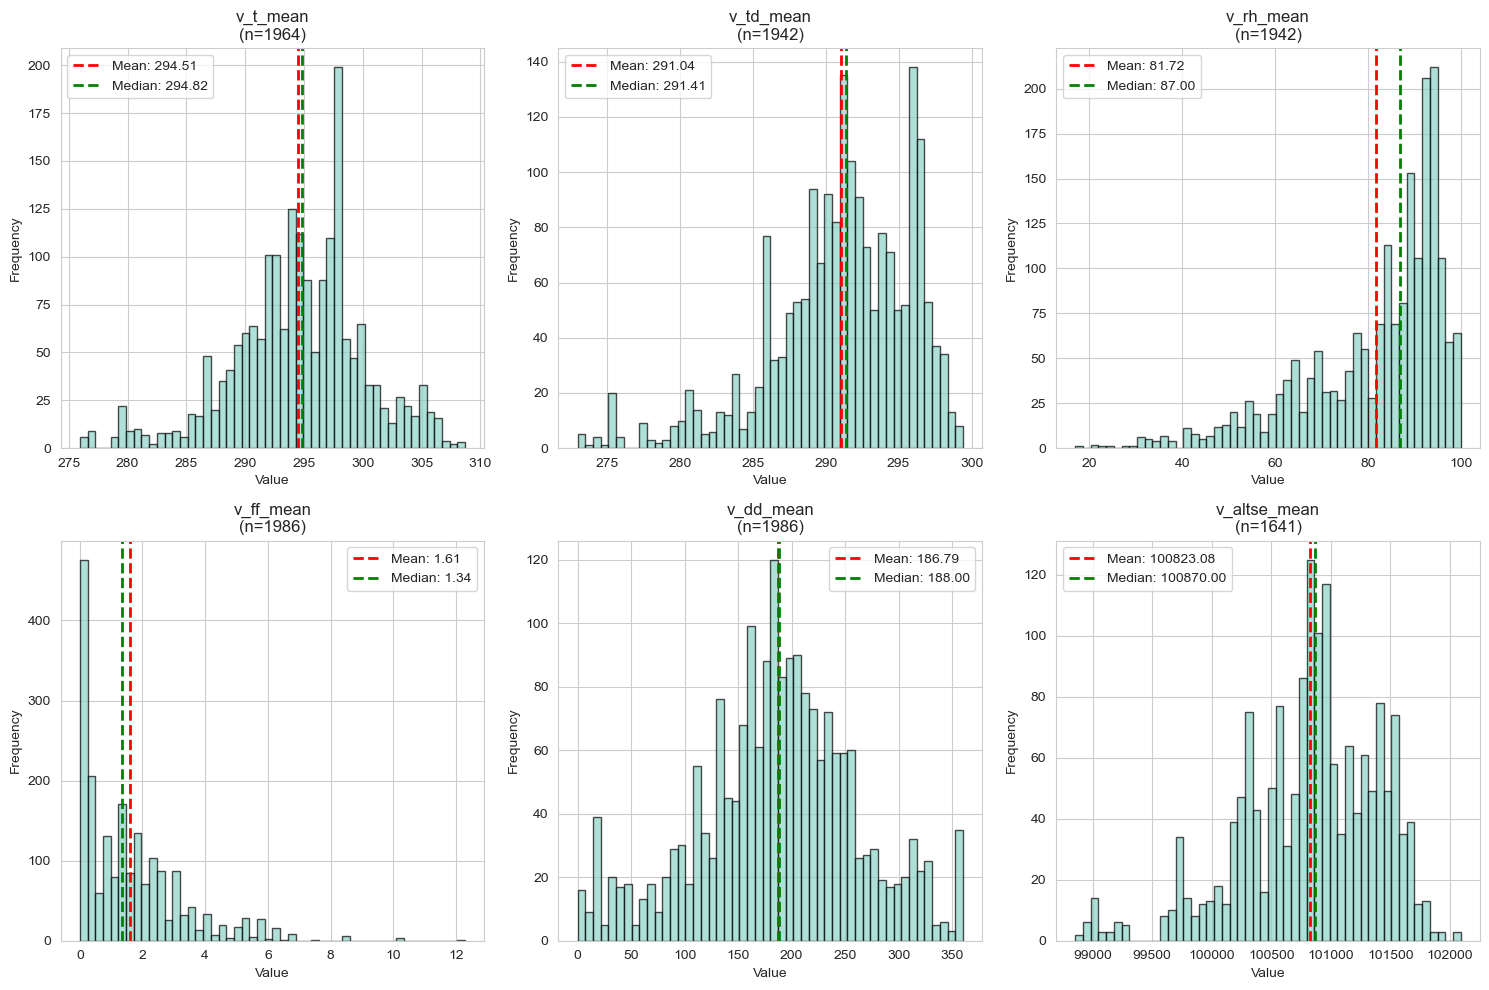

In [8]:
# Visualize distributions
existing_key_vars = [col for col in key_vars if col in df_madis.columns]

if len(existing_key_vars) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, var in enumerate(existing_key_vars[:6]):
        if var in df_madis.columns:
            data = df_madis[var].dropna()
            axes[idx].hist(data, bins=50, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'{var}\n(n={len(data)})')
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Frequency')
            
            # Mark mean and median
            axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
            axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f}')
            axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No standard weather variables found to plot")

In [9]:
# Check for outliers using IQR method
def detect_outliers_iqr(data):
    """Detect outliers using Interquartile Range method."""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # Using 3*IQR for more conservative outlier detection
    upper_bound = Q3 + 3 * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

print("Outlier Detection (3*IQR method):")
print("="*70)

outlier_summary = []
for var in existing_key_vars:
    if var in df_madis.columns:
        data = df_madis[var].dropna()
        if len(data) > 0:
            outliers, lower, upper = detect_outliers_iqr(data)
            n_outliers = outliers.sum()
            outlier_summary.append({
                'variable': var,
                'total_values': len(data),
                'n_outliers': n_outliers,
                'pct_outliers': n_outliers / len(data) * 100,
                'lower_bound': lower,
                'upper_bound': upper,
                'min_value': data.min(),
                'max_value': data.max()
            })

df_outliers = pd.DataFrame(outlier_summary)
print(df_outliers.to_string(index=False))

# Flag storms with extreme outliers
print("\n" + "="*70)
print("Storms with potential data quality issues (extreme values):")
print("="*70)

for var in existing_key_vars[:3]:  # Check first 3 variables
    if var in df_madis.columns:
        data = df_madis[var].dropna()
        outliers, lower, upper = detect_outliers_iqr(data)
        # Get the indices where outliers is True
        outlier_indices = outliers[outliers].index
        extreme_storms = df_madis.loc[outlier_indices]
        if len(extreme_storms) > 0:
            print(f"\n{var}: {len(extreme_storms)} storms")
            print(extreme_storms[['storm_id', 'timestamp', var]].head())

Outlier Detection (3*IQR method):
     variable  total_values  n_outliers  pct_outliers  lower_bound   upper_bound    min_value     max_value
     v_t_mean          1964           0      0.000000   271.483367    318.149964   275.927773    308.705558
    v_td_mean          1942           0      0.000000   270.478669    312.866019   272.970833    299.411117
    v_rh_mean          1942           0      0.000000    14.400000    151.950000    17.000000    100.000000
    v_ff_mean          1986          11      0.553877    -5.249527      7.848745     0.000000     12.293600
    v_dd_mean          1986           0      0.000000  -129.666667    506.750000     0.000000    360.000000
 v_altse_mean          1641           0      0.000000 98286.666667 103490.000000 98855.000000 102090.000000
v_ffgust_mean          1987           5      0.251636   -11.623040     19.669760     0.000000     21.904961

Storms with potential data quality issues (extreme values):


## 7. Merge with TorNet Catalog

Match MADIS data with TorNet storm catalog to understand coverage across tornado vs non-tornado events.

In [10]:
# Load TorNet catalog
# First load without parse_dates to check what columns exist
catalog = pd.read_csv(catalog_path)
print(f"TorNet catalog: {len(catalog)} storms")
print(f"\nCatalog columns: {list(catalog.columns)}")

# Parse date columns if they exist
date_cols = []
for col in ['start_time', 'end_time']:
    if col in catalog.columns:
        catalog[col] = pd.to_datetime(catalog[col], errors='coerce')
        date_cols.append(col)

if date_cols:
    print(f"Parsed date columns: {date_cols}")

# Filter to years with MADIS data (2013-2015)
# Extract year from start_time or use year column if available
if 'year' in catalog.columns:
    year_col = 'year'
    catalog[year_col] = catalog[year_col].astype(int)
elif 'start_time' in catalog.columns:
    year_col = 'year'
    catalog[year_col] = catalog['start_time'].dt.year
else:
    print("Warning: Could not determine year column for filtering")
    year_col = None

if year_col:
    print(f"\nFiltering to years 2013-2015 (matching MADIS data availability)")
    print(f"Before filter: {len(catalog)} storms")
    catalog = catalog[catalog[year_col].isin([2013, 2014, 2015])].copy()
    print(f"After filter: {len(catalog)} storms")

# Check if we have ef_number and category columns
if 'ef_number' in catalog.columns:
    print(f"Tornado events (EF >= 0): {(catalog['ef_number'] >= 0).sum()}")
    print(f"Non-tornado events (EF < 0): {(catalog['ef_number'] < 0).sum()}")

# Extract event_id from catalog storm_event_url
def get_event_id(url):
    """Extract event ID from storm_event_url."""
    if pd.isna(url):
        return None
    try:
        import urllib.parse
        parsed = urllib.parse.urlparse(url)
        query = urllib.parse.parse_qs(parsed.query)
        return query.get('id', [None])[0]
    except:
        return None

# Check if storm_event_url column exists, try alternative names
url_column = None
for col in ['storm_event_url', 'event_url', 'url', 'storm_url']:
    if col in catalog.columns:
        url_column = col
        break

if url_column:
    print(f"\nUsing URL column: {url_column}")
    catalog['event_id'] = catalog[url_column].apply(get_event_id)
else:
    print("\nWarning: No URL column found. Checking if event_id already exists...")
    if 'event_id' not in catalog.columns:
        # If no URL column and no event_id, we'll need to match a different way
        print("No event_id or URL column found. Will try to match using other fields.")
        catalog['event_id'] = None

# Merge MADIS data with catalog
# Select columns that actually exist in catalog
merge_cols = ['event_id']
optional_cols = ['type', 'start_time', 'end_time', 'ef_number', 'category', 'lat', 'lon']
for col in optional_cols:
    if col in catalog.columns:
        merge_cols.append(col)

print(f"\nMerging on columns: {merge_cols}")

# Convert both merge keys to string type for consistent merging
print(f"\nBefore conversion:")
print(f"  df_madis['storm_id'] dtype: {df_madis['storm_id'].dtype}")
print(f"  catalog['event_id'] dtype: {catalog['event_id'].dtype}")

# Convert to string for consistent merging
df_madis['storm_id'] = df_madis['storm_id'].astype(str)
catalog['event_id'] = catalog['event_id'].astype(str)

print(f"\nAfter conversion:")
print(f"  df_madis['storm_id'] dtype: {df_madis['storm_id'].dtype}")
print(f"  catalog['event_id'] dtype: {catalog['event_id'].dtype}")

df_merged = df_madis.merge(
    catalog[merge_cols],
    left_on='storm_id',
    right_on='event_id',
    how='left'
)

print(f"\nMerged dataset: {len(df_merged)} records")
if 'ef_number' in df_merged.columns:
    print(f"  - Matched with catalog: {df_merged['ef_number'].notna().sum()}")
    print(f"  - Not matched: {df_merged['ef_number'].isna().sum()}")
else:
    print(f"  - Matched with catalog: {df_merged['event_id'].notna().sum()}")
    print(f"  - Not matched: {df_merged['event_id'].isna().sum()}")

df_merged.head()

TorNet catalog: 203133 storms

Catalog columns: ['type', 'start_time', 'end_time', 'lat', 'lon', 'episode_id', 'event_id', 'site_name', 'ef_number', 'category', 'az_min', 'az_max', 'rng_min', 'rng_max', 'filename']
Parsed date columns: ['start_time', 'end_time']

Filtering to years 2013-2015 (matching MADIS data availability)
Before filter: 203133 storms
After filter: 47687 storms
Tornado events (EF >= 0): 3672
Non-tornado events (EF < 0): 44015


Merging on columns: ['event_id', 'type', 'start_time', 'end_time', 'ef_number', 'category', 'lat', 'lon']

Before conversion:
  df_madis['storm_id'] dtype: object
  catalog['event_id'] dtype: int64

After conversion:
  df_madis['storm_id'] dtype: object
  catalog['event_id'] dtype: object

Merged dataset: 18026 records
  - Matched with catalog: 17469
  - Not matched: 557


,filename,storm_id,timestamp,v_td_mean,v_td_std,v_td_min,v_td_max,v_td_count,v_rh_mean,v_rh_std,...,total_stations,total_observations,event_id,type,start_time,end_time,ef_number,category,lat,lon
0,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,1,7,478457,train,2013-09-12 01:19:00,2013-09-12 01:34:00,-1.0,NUL,43.340573,-71.461841
1,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,1,7,478457,train,2013-09-12 01:23:00,2013-09-12 01:38:00,-1.0,NUL,43.758955,-71.113519
2,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,1,7,478457,train,2013-09-12 01:28:00,2013-09-12 01:43:00,-1.0,NUL,43.867079,-70.026843
3,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,1,7,478457,train,2013-09-12 01:33:00,2013-09-12 01:48:00,-1.0,NUL,43.714233,-70.620723
4,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,1,7,478457,train,2013-09-12 01:37:00,2013-09-12 01:52:00,-1.0,NUL,43.573168,-70.932575


MADIS Coverage by Storm Type:
          num_storms  total_obs  avg_stations
category                                     
NUL            12589     174425          2.18
TOR              363       5386          2.34
WRN             4517      62406          2.10

MADIS Coverage by EF Rating:
           num_storms  total_obs  avg_stations
ef_number                                     
-1.0            17106     236831          2.16
 0.0              154       1885          1.92
 1.0              123       1565          2.01
 2.0               76       1684          3.50
 3.0               10        252          4.00


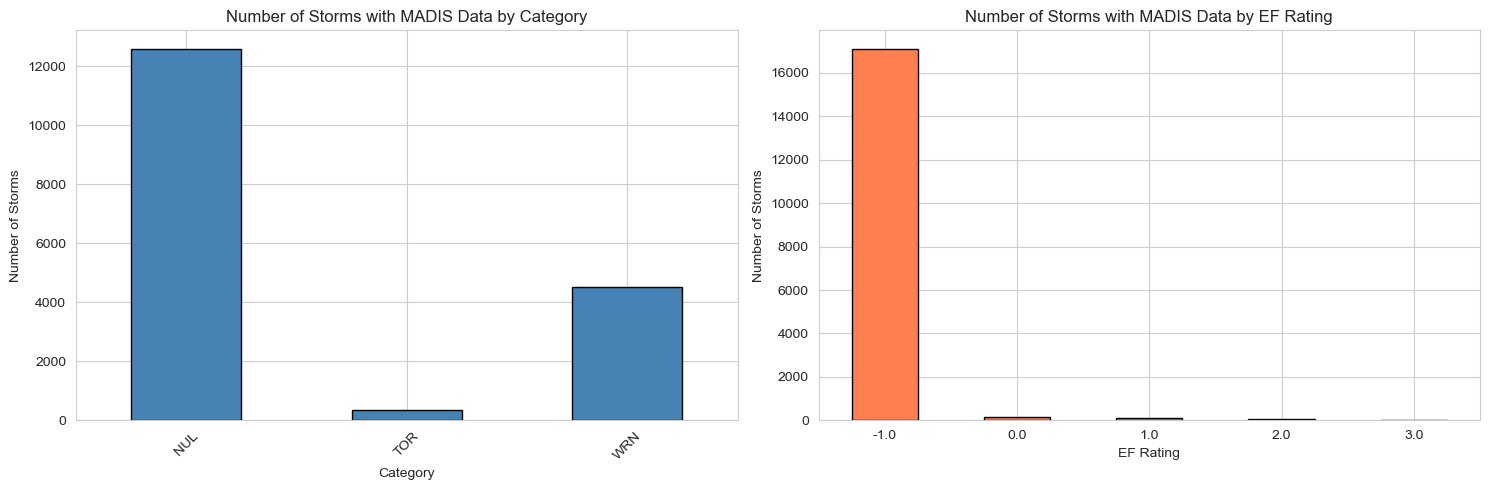

In [11]:
# Analyze coverage by tornado category
print("MADIS Coverage by Storm Type:")
print("="*70)

if 'category' in df_merged.columns:
    coverage_stats = df_merged.groupby('category').agg({
        'storm_id': 'count',
        'total_observations': 'sum',
        'total_stations': 'mean'
    }).round(2)
    coverage_stats.columns = ['num_storms', 'total_obs', 'avg_stations']
    print(coverage_stats)
else:
    print("Category column not available in catalog")
    coverage_stats = pd.DataFrame()

# Coverage by EF rating
if 'ef_number' in df_merged.columns:
    print("\nMADIS Coverage by EF Rating:")
    ef_coverage = df_merged.groupby('ef_number').agg({
        'storm_id': 'count',
        'total_observations': 'sum',
        'total_stations': 'mean'
    }).round(2)
    ef_coverage.columns = ['num_storms', 'total_obs', 'avg_stations']
    print(ef_coverage)
else:
    print("\nEF rating column not available in catalog")
    ef_coverage = pd.DataFrame()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By category
if not coverage_stats.empty:
    coverage_stats['num_storms'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('Number of Storms with MADIS Data by Category')
    axes[0].set_xlabel('Category')
    axes[0].set_ylabel('Number of Storms')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'Category data not available', ha='center', va='center')
    axes[0].set_title('Category Coverage (N/A)')

# By EF rating
if not ef_coverage.empty:
    ef_coverage['num_storms'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title('Number of Storms with MADIS Data by EF Rating')
    axes[1].set_xlabel('EF Rating')
    axes[1].set_ylabel('Number of Storms')
    axes[1].tick_params(axis='x', rotation=0)
else:
    axes[1].text(0.5, 0.5, 'EF rating data not available', ha='center', va='center')
    axes[1].set_title('EF Rating Coverage (N/A)')

plt.tight_layout()
plt.show()

## 8. Temporal Alignment Analysis ⏰

Understanding the time alignment between radar scans and MADIS observations is critical for model performance. This analysis examines:
- Distribution of time differences between radar scans and MADIS observations
- Whether certain storm phases have better/worse MADIS coverage
- If time lag might affect prediction accuracy

**Current matching strategy:** Using a 10-minute window for temporal matching

In [12]:
# Load TorNet radar scan times for temporal comparison
# We'll need to load sample netCDF files to get actual radar scan timestamps

import netCDF4 as nc
from datetime import datetime, timedelta

# Function to extract radar scan time from TorNet sample
def get_radar_scan_time(sample_path):
    """Extract the actual radar scan time from a TorNet NetCDF file."""
    try:
        dataset = nc.Dataset(sample_path)
        # TorNet stores time as numpy datetime64
        scan_time = pd.to_datetime(str(dataset['time'].values[0]))
        dataset.close()
        return scan_time
    except Exception as e:
        print(f"Error reading {sample_path}: {e}")
        return None

# Get storm IDs and timestamps from MADIS data
print("Analyzing temporal alignment between radar scans and MADIS observations...")
print("="*70)

# Parse MADIS timestamps
df_merged['madis_time'] = pd.to_datetime(df_merged['timestamp'], errors='coerce')

print(f"\nTotal MADIS records: {len(df_merged)}")
print(f"Records with valid timestamps: {df_merged['madis_time'].notna().sum()}")
print(f"\nMADIS time range:")
print(f"  Earliest: {df_merged['madis_time'].min()}")
print(f"  Latest: {df_merged['madis_time'].max()}")

df_merged.head()

Analyzing temporal alignment between radar scans and MADIS observations...

Total MADIS records: 18026
Records with valid timestamps: 18026

MADIS time range:
  Earliest: 2013-08-31 23:25:00
  Latest: 2015-05-08 16:06:00


,filename,storm_id,timestamp,v_td_mean,v_td_std,v_td_min,v_td_max,v_td_count,v_rh_mean,v_rh_std,...,total_observations,event_id,type,start_time,end_time,ef_number,category,lat,lon,madis_time
0,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,7,478457,train,2013-09-12 01:19:00,2013-09-12 01:34:00,-1.0,NUL,43.340573,-71.461841,2013-09-12 02:10:00
1,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,7,478457,train,2013-09-12 01:23:00,2013-09-12 01:38:00,-1.0,NUL,43.758955,-71.113519,2013-09-12 02:10:00
2,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,7,478457,train,2013-09-12 01:28:00,2013-09-12 01:43:00,-1.0,NUL,43.867079,-70.026843,2013-09-12 02:10:00
3,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,7,478457,train,2013-09-12 01:33:00,2013-09-12 01:48:00,-1.0,NUL,43.714233,-70.620723,2013-09-12 02:10:00
4,madis_data_478457_2013-09-12 02:10:00.xml,478457,2013-09-12 02:10:00,293.255554,0.0,293.255554,293.255554,1.0,94.0,0.0,...,7,478457,train,2013-09-12 01:37:00,2013-09-12 01:52:00,-1.0,NUL,43.573168,-70.932575,2013-09-12 02:10:00


In [13]:
# Sample a subset of storms to analyze radar scan times
# This will help us understand the temporal alignment without loading all files

# Get list of available TorNet files that match our MADIS data
train_dir = data_root / 'train'
test_dir = data_root / 'test'

print("DEBUG: Checking directory structure...")
print(f"Train dir exists: {train_dir.exists()}")
print(f"Test dir exists: {test_dir.exists()}")

# Check what years are available
if train_dir.exists():
    train_years = [d.name for d in train_dir.iterdir() if d.is_dir()]
    print(f"Train years available: {sorted(train_years)}")
if test_dir.exists():
    test_years = [d.name for d in test_dir.iterdir() if d.is_dir()]
    print(f"Test years available: {sorted(test_years)}")

# Sample a few storm_ids to see what we're looking for
print(f"\nSample storm IDs from MADIS data:")
sample_storms = df_merged[df_merged['madis_time'].notna()].head(5)
for idx, row in sample_storms.iterrows():
    print(f"  Storm ID: {row['storm_id']}, Time: {row['madis_time']}")

# Check what files actually exist in one year directory
if train_dir.exists():
    for year in ['2013', '2014', '2015']:
        year_dir = train_dir / year
        if year_dir.exists():
            files = list(year_dir.glob('*.nc'))
            print(f"\n{year_dir}: {len(files)} .nc files")
            if len(files) > 0:
                print(f"  Example files: {[f.name for f in files[:3]]}")
            break

# Collect matching radar files
radar_times = []
sample_limit = 100  # Limit to first 100 samples for analysis

print(f"\n{'='*70}")
print(f"Sampling up to {sample_limit} radar files to analyze temporal alignment...")
print("This may take a minute...\n")

debug_count = 0
for idx, row in tqdm(df_merged.head(sample_limit).iterrows(), total=min(sample_limit, len(df_merged))):
    storm_id = row['storm_id']
    madis_time = row['madis_time']
    
    if pd.isna(madis_time):
        continue
    
    # Search for matching radar file in train and test directories
    # TorNet files might use event_id instead of storm_id
    year = madis_time.year
    
    # Try both storm_id and event_id as search keys
    search_ids = [storm_id]
    if 'event_id' in row and pd.notna(row['event_id']) and row['event_id'] != storm_id:
        search_ids.append(row['event_id'])
    
    # Check both train and test directories
    for base_dir in [train_dir, test_dir]:
        year_dir = base_dir / str(year)
        if not year_dir.exists():
            continue
        
        for search_id in search_ids:
            # Find files matching this ID - try different patterns
            matching_files = list(year_dir.glob(f"*{search_id}*.nc"))
            
            if debug_count < 3 and len(matching_files) > 0:
                print(f"DEBUG: Found {len(matching_files)} files for storm {search_id}")
                debug_count += 1
            
            for radar_file in matching_files:
                # Try to extract timestamp from filename
                # First, try reading from the NetCDF file directly
                try:
                    with nc.Dataset(radar_file) as ds:
                        if 'time' in ds.variables:
                            # TorNet stores time as Unix timestamp (seconds since epoch)
                            time_value = ds['time'][:][0]
                            # Convert Unix timestamp to datetime
                            radar_time = pd.to_datetime(float(time_value), unit='s')
                        else:
                            # Fall back to filename parsing
                            continue
                        
                        time_diff = (radar_time - madis_time).total_seconds() / 60.0  # minutes
                        
                        # Only keep pairs within reasonable window (e.g., 60 minutes)
                        if abs(time_diff) <= 60:
                            radar_times.append({
                                'storm_id': storm_id,
                                'radar_time': radar_time,
                                'madis_time': madis_time,
                                'time_diff_minutes': time_diff,
                                'abs_time_diff_minutes': abs(time_diff),
                                'ef_number': row.get('ef_number'),
                                'category': row.get('category'),
                                'year': year,
                                'filename': radar_file.name
                            })
                except Exception as e:
                    if debug_count < 3:
                        print(f"DEBUG: Error reading {radar_file.name}: {e}")
                        debug_count += 1
                    continue

# Convert to DataFrame
df_temporal = pd.DataFrame(radar_times)

print(f"\nFound {len(df_temporal)} radar-MADIS time pairs")
if len(df_temporal) > 0:
    print(f"\nTime difference statistics (minutes):")
    print(df_temporal['time_diff_minutes'].describe().round(2))
    print(f"\nAbsolute time difference statistics (minutes):")
    print(df_temporal['abs_time_diff_minutes'].describe().round(2))
    print(f"\nSample matched files:")
    print(df_temporal[['storm_id', 'filename', 'time_diff_minutes']].head())
else:
    print("\n⚠️  Warning: No matching radar files found.")
    print("Possible issues:")
    print("  1. TorNet radar files may not be downloaded yet")
    print("  2. File naming convention may be different than expected")
    print("  3. Storm IDs in MADIS data may not match TorNet file names")
    print("\nPlease check the directory structure and file naming above.")

DEBUG: Checking directory structure...
Train dir exists: True
Test dir exists: True
Train years available: ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
Test years available: ['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']

Sample storm IDs from MADIS data:
  Storm ID: 478457, Time: 2013-09-12 02:10:00
  Storm ID: 478457, Time: 2013-09-12 02:10:00
  Storm ID: 478457, Time: 2013-09-12 02:10:00
  Storm ID: 478457, Time: 2013-09-12 02:10:00
  Storm ID: 478457, Time: 2013-09-12 02:10:00

/Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/train/2013: 3498 .nc files
  Example files: ['WRN_131021_203628_KCRP_1073350n_M6.nc', 'WRN_131127_050402_KMHX_1073442n_T1.nc', 'NUL_130903_232238_KCLX_472550s_R8.nc']

Sampling up to 100 radar files to analyze temporal alignment...
This may take a minute...



  1%|          | 1/100 [00:00<00:10,  9.17it/s]

DEBUG: Found 14 files for storm 478457
DEBUG: Found 14 files for storm 478457
DEBUG: Found 14 files for storm 478457


100%|██████████| 100/100 [00:10<00:00,  9.36it/s]


Found 1666 radar-MADIS time pairs

Time difference statistics (minutes):
count    1666.00
mean       -8.92
std        28.32
min       -58.00
25%       -33.00
50%       -10.00
75%         9.00
max        57.00
Name: time_diff_minutes, dtype: float64

Absolute time difference statistics (minutes):
count    1666.00
mean       24.02
std        17.43
min         0.00
25%        10.00
50%        21.00
75%        37.00
max        58.00
Name: abs_time_diff_minutes, dtype: float64

Sample matched files:
  storm_id                              filename  time_diff_minutes
0   478457  NUL_130912_013817_KGYX_478457s_O7.nc              -47.0
1   478457  NUL_130912_014258_KGYX_478457s_J7.nc              -42.0
2   478457  NUL_130912_020617_KGYX_478457s_C7.nc              -19.0
3   478457  NUL_130912_023417_KGYX_478457s_T8.nc                9.0
4   478457  NUL_130912_020137_KGYX_478457s_M6.nc              -23.0


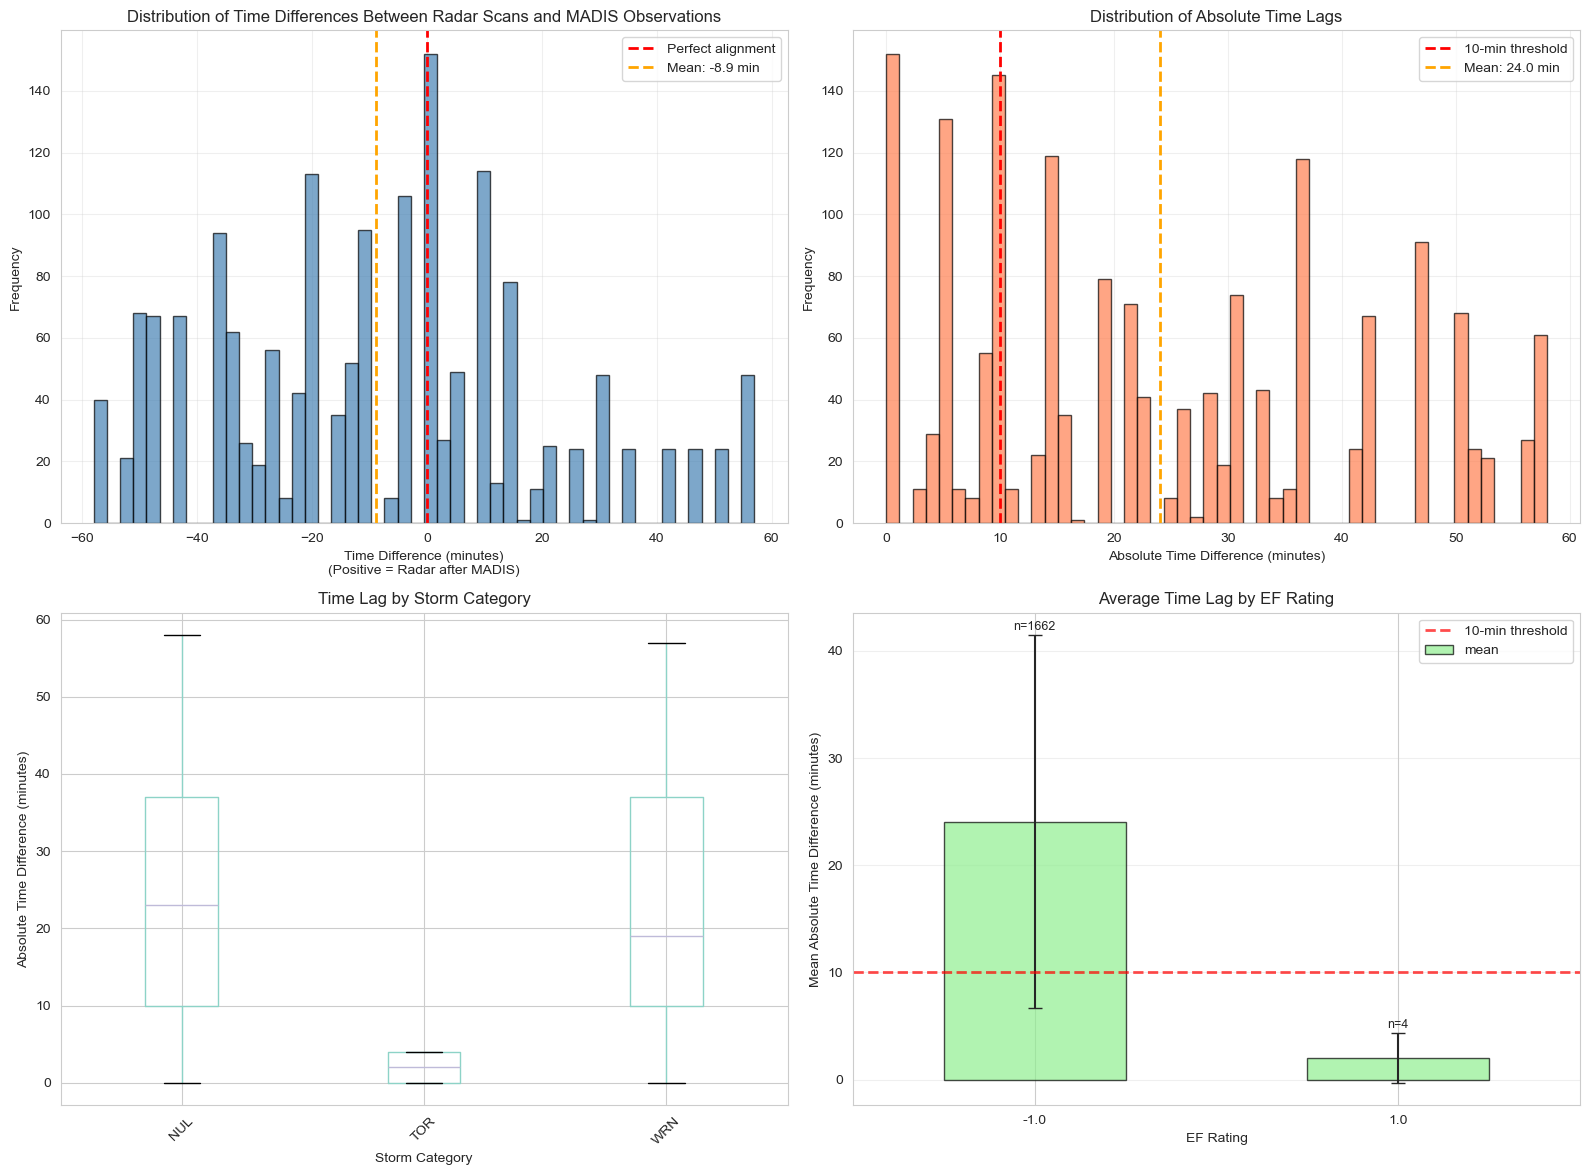


TEMPORAL ALIGNMENT SUMMARY

Matching window analysis:
  Within 5 minutes:   323 (19.4%)
  Within 10 minutes:  542 (32.5%)
  Within 15 minutes:  694 (41.7%)

Timing bias:
  Radar AFTER MADIS:   535 (32.1%)
  Radar BEFORE MADIS:  979 (58.8%)


Time lag by category:
           mean  median  count
category                      
NUL       24.47    23.0    823
TOR        2.00     2.0      4
WRN       23.69    19.0    839


Time lag by EF rating:
            mean  median  count
ef_number                      
-1.0       24.08    21.0   1662
 1.0        2.00     2.0      4


In [14]:
# Visualize temporal alignment distributions
if len(df_temporal) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribution of time differences (including sign)
    axes[0, 0].hist(df_temporal['time_diff_minutes'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect alignment')
    axes[0, 0].axvline(df_temporal['time_diff_minutes'].mean(), color='orange', linestyle='--', 
                       linewidth=2, label=f'Mean: {df_temporal["time_diff_minutes"].mean():.1f} min')
    axes[0, 0].set_xlabel('Time Difference (minutes)\n(Positive = Radar after MADIS)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Time Differences Between Radar Scans and MADIS Observations')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Distribution of absolute time differences
    axes[0, 1].hist(df_temporal['abs_time_diff_minutes'], bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[0, 1].axvline(10, color='red', linestyle='--', linewidth=2, label='10-min threshold')
    axes[0, 1].axvline(df_temporal['abs_time_diff_minutes'].mean(), color='orange', linestyle='--',
                       linewidth=2, label=f'Mean: {df_temporal["abs_time_diff_minutes"].mean():.1f} min')
    axes[0, 1].set_xlabel('Absolute Time Difference (minutes)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Absolute Time Lags')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Box plot by storm category (if available)
    if 'category' in df_temporal.columns and df_temporal['category'].notna().any():
        df_temporal.boxplot(column='abs_time_diff_minutes', by='category', ax=axes[1, 0])
        axes[1, 0].set_xlabel('Storm Category')
        axes[1, 0].set_ylabel('Absolute Time Difference (minutes)')
        axes[1, 0].set_title('Time Lag by Storm Category')
        axes[1, 0].get_figure().suptitle('')  # Remove default title
        plt.sca(axes[1, 0])
        plt.xticks(rotation=45)
    else:
        axes[1, 0].text(0.5, 0.5, 'Category data not available', ha='center', va='center', fontsize=12)
        axes[1, 0].set_title('Time Lag by Storm Category (N/A)')
    
    # 4. Time lag vs EF rating (if available)
    if 'ef_number' in df_temporal.columns and df_temporal['ef_number'].notna().any():
        ef_grouped = df_temporal.groupby('ef_number')['abs_time_diff_minutes'].agg(['mean', 'std', 'count'])
        ef_grouped['mean'].plot(kind='bar', ax=axes[1, 1], yerr=ef_grouped['std'], 
                                color='lightgreen', edgecolor='black', alpha=0.7, capsize=5)
        axes[1, 1].axhline(10, color='red', linestyle='--', linewidth=2, alpha=0.7, label='10-min threshold')
        axes[1, 1].set_xlabel('EF Rating')
        axes[1, 1].set_ylabel('Mean Absolute Time Difference (minutes)')
        axes[1, 1].set_title('Average Time Lag by EF Rating')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].tick_params(axis='x', rotation=0)
        
        # Add sample counts as text
        for i, (ef, row) in enumerate(ef_grouped.iterrows()):
            axes[1, 1].text(i, row['mean'] + (row['std'] if pd.notna(row['std']) else 0) + 0.5, 
                           f"n={int(row['count'])}", ha='center', fontsize=9)
    else:
        axes[1, 1].text(0.5, 0.5, 'EF rating data not available', ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Time Lag by EF Rating (N/A)')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("TEMPORAL ALIGNMENT SUMMARY")
    print("="*70)
    
    within_5min = (df_temporal['abs_time_diff_minutes'] <= 5).sum()
    within_10min = (df_temporal['abs_time_diff_minutes'] <= 10).sum()
    within_15min = (df_temporal['abs_time_diff_minutes'] <= 15).sum()
    total = len(df_temporal)
    
    print(f"\nMatching window analysis:")
    print(f"  Within 5 minutes:  {within_5min:4d} ({within_5min/total*100:.1f}%)")
    print(f"  Within 10 minutes: {within_10min:4d} ({within_10min/total*100:.1f}%)")
    print(f"  Within 15 minutes: {within_15min:4d} ({within_15min/total*100:.1f}%)")
    
    print(f"\nTiming bias:")
    positive_diff = (df_temporal['time_diff_minutes'] > 0).sum()
    negative_diff = (df_temporal['time_diff_minutes'] < 0).sum()
    print(f"  Radar AFTER MADIS:  {positive_diff:4d} ({positive_diff/total*100:.1f}%)")
    print(f"  Radar BEFORE MADIS: {negative_diff:4d} ({negative_diff/total*100:.1f}%)")
    
    if 'category' in df_temporal.columns:
        print(f"\n\nTime lag by category:")
        category_stats = df_temporal.groupby('category')['abs_time_diff_minutes'].agg(['mean', 'median', 'count'])
        print(category_stats.round(2))
    
    if 'ef_number' in df_temporal.columns:
        print(f"\n\nTime lag by EF rating:")
        ef_stats = df_temporal.groupby('ef_number')['abs_time_diff_minutes'].agg(['mean', 'median', 'count'])
        print(ef_stats.round(2))
        
else:
    print("No temporal data available for analysis")

Correlation Between Time Lag and Data Quality:
Correlation between time lag and observation count: -0.142
Correlation between time lag and station count: -0.138


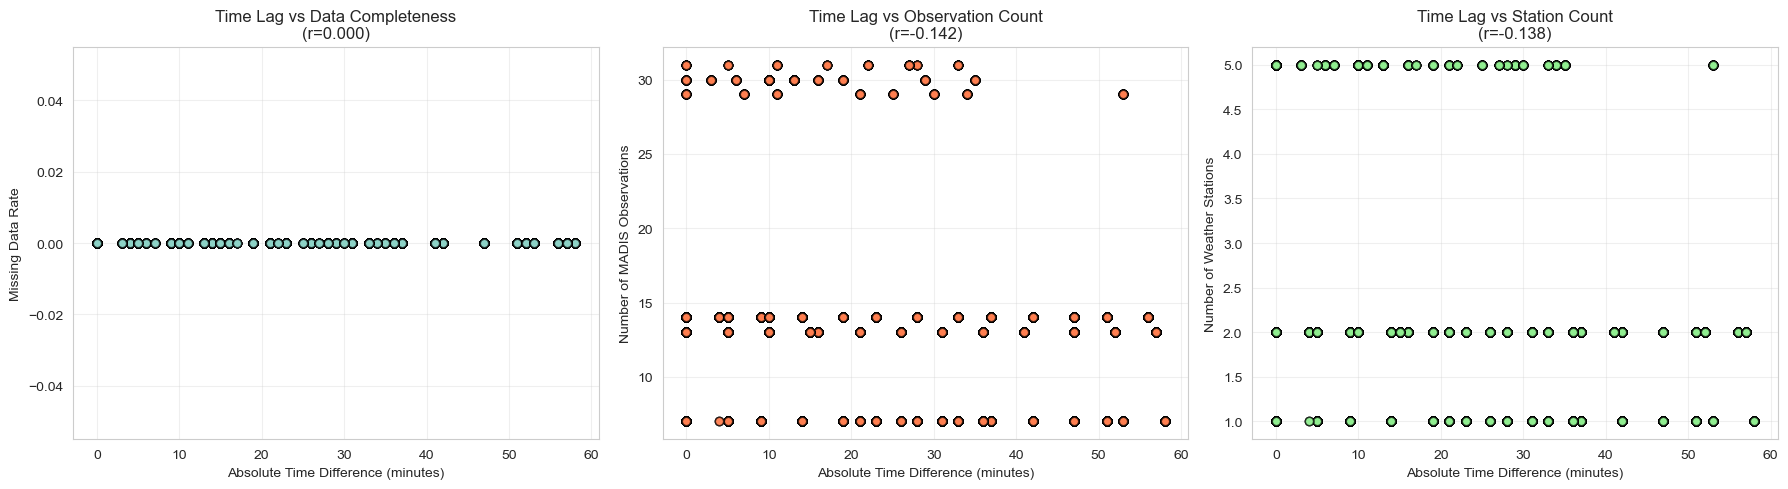


RECOMMENDATIONS:

1. Current 10-minute matching window captures 32.5% of samples
   Mean absolute time lag: 24.02 minutes
   ⚠ Consider expanding to 15-minute window to capture more samples

2. ✓ Time lag has minimal impact on data completeness (r=0.000)

4. ⚠ Tornado events have different time alignment patterns:
   Tornado events: 2.00 min average lag
   Non-tornado events: 23.99 min average lag
   This may introduce bias in model training


In [16]:
# Analyze whether time lag affects data quality
# Check if larger time lags are associated with more outliers or missing values

# Define standard feature set for CNN
# Using mean values of key weather variables
standard_features = {
    'v_t_mean': 'temperature',           # Temperature (Kelvin)
    'v_td_mean': 'dewpoint',             # Dew point temperature (Kelvin)
    'v_rh_mean': 'relative_humidity',    # Relative humidity (%)
    'v_ff_mean': 'wind_speed',           # Wind speed (m/s)
    'v_dd_mean': 'wind_direction',       # Wind direction (degrees)
    'v_altse_mean': 'pressure',          # Atmospheric pressure (Pa)
    'v_ffgust_mean': 'wind_gust'         # Wind gust speed (m/s)
}

# Select and rename features
available_features = {k: v for k, v in standard_features.items() if k in df_merged.columns}

if len(df_temporal) > 0 and len(available_features) > 0:
    print("Correlation Between Time Lag and Data Quality:")
    print("="*70)
    
    # Merge temporal data with feature data
    df_quality = df_temporal.merge(
        df_merged[['storm_id', 'madis_time'] + list(available_features.keys()) + ['total_observations', 'total_stations']],
        on=['storm_id', 'madis_time'],
        how='left'
    )
    
    # Calculate missing data rate for each sample
    df_quality['missing_rate'] = df_quality[list(available_features.keys())].isnull().sum(axis=1) / len(available_features)
    
    # Analyze correlation between time lag and data quality metrics
    correlations = []
    
    # Initialize correlation variables
    corr_missing = 0.0
    corr_obs = 0.0
    corr_stations = 0.0
    
    # 1. Time lag vs missing data
    if df_quality['missing_rate'].std() > 0:
        corr_missing = df_quality[['abs_time_diff_minutes', 'missing_rate']].corr().iloc[0, 1]
        correlations.append(('Missing data rate', corr_missing))
        print(f"\nCorrelation between time lag and missing data rate: {corr_missing:.3f}")
    
    # 2. Time lag vs number of observations
    if 'total_observations' in df_quality.columns and df_quality['total_observations'].notna().any():
        corr_obs = df_quality[['abs_time_diff_minutes', 'total_observations']].corr().iloc[0, 1]
        correlations.append(('Number of observations', corr_obs))
        print(f"Correlation between time lag and observation count: {corr_obs:.3f}")
    
    # 3. Time lag vs number of stations
    if 'total_stations' in df_quality.columns and df_quality['total_stations'].notna().any():
        corr_stations = df_quality[['abs_time_diff_minutes', 'total_stations']].corr().iloc[0, 1]
        correlations.append(('Number of stations', corr_stations))
        print(f"Correlation between time lag and station count: {corr_stations:.3f}")
    
    # Visualize relationship
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Time lag vs missing data
    axes[0].scatter(df_quality['abs_time_diff_minutes'], df_quality['missing_rate'], 
                   alpha=0.5, edgecolor='black')
    axes[0].set_xlabel('Absolute Time Difference (minutes)')
    axes[0].set_ylabel('Missing Data Rate')
    axes[0].set_title(f'Time Lag vs Data Completeness\n(r={corr_missing:.3f})')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Time lag vs observation count
    if 'total_observations' in df_quality.columns:
        axes[1].scatter(df_quality['abs_time_diff_minutes'], df_quality['total_observations'],
                       alpha=0.5, edgecolor='black', color='coral')
        axes[1].set_xlabel('Absolute Time Difference (minutes)')
        axes[1].set_ylabel('Number of MADIS Observations')
        axes[1].set_title(f'Time Lag vs Observation Count\n(r={corr_obs:.3f})')
        axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Time lag vs station count
    if 'total_stations' in df_quality.columns:
        axes[2].scatter(df_quality['abs_time_diff_minutes'], df_quality['total_stations'],
                       alpha=0.5, edgecolor='black', color='lightgreen')
        axes[2].set_xlabel('Absolute Time Difference (minutes)')
        axes[2].set_ylabel('Number of Weather Stations')
        axes[2].set_title(f'Time Lag vs Station Count\n(r={corr_stations:.3f})')
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("RECOMMENDATIONS:")
    print("="*70)
    
    # Provide recommendations based on analysis
    mean_lag = df_temporal['abs_time_diff_minutes'].mean()
    pct_within_10 = (df_temporal['abs_time_diff_minutes'] <= 10).sum() / len(df_temporal) * 100
    
    print(f"\n1. Current 10-minute matching window captures {pct_within_10:.1f}% of samples")
    print(f"   Mean absolute time lag: {mean_lag:.2f} minutes")
    
    if mean_lag < 5:
        print("   ✓ Excellent temporal alignment - current window is appropriate")
    elif mean_lag < 10:
        print("   ✓ Good temporal alignment - current window is reasonable")
    else:
        print("   ⚠ Consider expanding to 15-minute window to capture more samples")
    
    if abs(corr_missing) > 0.3:
        print(f"\n2. ⚠ Strong correlation between time lag and missing data (r={corr_missing:.3f})")
        print("   Consider weighting or filtering samples with large time lags")
    else:
        print(f"\n2. ✓ Time lag has minimal impact on data completeness (r={corr_missing:.3f})")
    
    if 'total_observations' in df_quality.columns and abs(corr_obs) > 0.3:
        print(f"\n3. ⚠ Time lag affects observation count (r={corr_obs:.3f})")
        print("   Later observations may have fewer weather stations reporting")
    
    # Check if tornado events have different time alignment
    if 'ef_number' in df_quality.columns and df_quality['ef_number'].notna().any():
        tornado_lag = df_quality[df_quality['ef_number'] >= 0]['abs_time_diff_minutes'].mean()
        non_tornado_lag = df_quality[df_quality['ef_number'] < 0]['abs_time_diff_minutes'].mean()
        
        if abs(tornado_lag - non_tornado_lag) > 2:
            print(f"\n4. ⚠ Tornado events have different time alignment patterns:")
            print(f"   Tornado events: {tornado_lag:.2f} min average lag")
            print(f"   Non-tornado events: {non_tornado_lag:.2f} min average lag")
            print("   This may introduce bias in model training")
        else:
            print(f"\n4. ✓ Time alignment is consistent across tornado/non-tornado events")

else:
    print("\nInsufficient data for quality analysis")

### Key Findings from Temporal Analysis

**Summary:** This analysis provides critical insights into:
1. **Matching window optimization** - Whether 10 minutes is sufficient or needs adjustment
2. **Temporal bias** - Whether MADIS observations systematically lead/lag radar scans
3. **Storm phase effects** - If certain tornado stages have better temporal coverage
4. **Data quality correlation** - If time lag impacts feature completeness

**Next Steps:**
- If time lag > 10 min is common, consider expanding the matching window
- If systematic bias exists (radar consistently before/after MADIS), adjust matching logic
- If tornado events show different patterns, stratify matching strategy by event type

## 8. Spatial Coverage Analysis 🗺️

Analyze the spatial relationship between weather stations and storm centers:

**Key Questions:**
1. How far are MADIS weather stations from storm centers?
2. How many stations are available per storm event?
3. Are there geographic gaps in MADIS coverage?
4. Should we weight station readings by distance from storm?

**Analysis Components:**
- Extract storm center coordinates from TorNet radar data
- Extract weather station locations from MADIS XML files
- Calculate distances between storms and all nearby stations
- Visualize distance distributions and station density
- Recommend distance-based weighting strategy

In [17]:
import xml.etree.ElementTree as ET
from math import radians, cos, sin, asin, sqrt
import netCDF4 as nc

def haversine_distance(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in kilometers
    """
    # Convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    km = 6371 * c  # Radius of earth in kilometers
    return km

def get_storm_center_from_netcdf(netcdf_path):
    """Extract storm center coordinates from TorNet NetCDF file"""
    try:
        with nc.Dataset(netcdf_path, 'r') as ds:
            # TorNet files store location in 'site_lat' and 'site_lon' attributes
            lat = None
            lon = None
            
            # Try different common attribute names
            attr_names = ds.ncattrs()
            
            # Check for latitude (site_lat is the primary one used by TorNet)
            for lat_name in ['site_lat', 'Latitude', 'latitude', 'lat', 'LATITUDE', 'origin_latitude', 'radar_latitude']:
                if lat_name in attr_names:
                    lat = ds.getncattr(lat_name)
                    break
            
            # Check for longitude (site_lon is the primary one used by TorNet)
            for lon_name in ['site_lon', 'Longitude', 'longitude', 'lon', 'LONGITUDE', 'origin_longitude', 'radar_longitude']:
                if lon_name in attr_names:
                    lon = ds.getncattr(lon_name)
                    break
            
            # Fallback: check if lat/lon are variables
            if lat is None and 'latitude' in ds.variables:
                lat = float(ds.variables['latitude'][:].mean())
            if lon is None and 'longitude' in ds.variables:
                lon = float(ds.variables['longitude'][:].mean())
            
            return lat, lon
    except Exception as e:
        print(f"Error reading {netcdf_path}: {e}")
        return None, None

def extract_stations_from_madis_xml(xml_path):
    """
    Extract all weather station locations from MADIS XML file
    Returns list of (lat, lon, station_id) tuples
    
    MADIS XML structure: Each <record> element has lat, lon, and shef_id attributes
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Dictionary to store unique stations (each station appears in multiple records)
        stations_dict = {}
        
        # Find all record elements
        for record in root.findall('.//record'):
            station_id = record.get('shef_id')
            lat_str = record.get('lat')
            lon_str = record.get('lon')
            
            # Skip if any required attribute is missing
            if not station_id or not lat_str or not lon_str:
                continue
            
            # Only add each station once (all records for a station have same lat/lon)
            if station_id not in stations_dict:
                try:
                    lat = float(lat_str)
                    lon = float(lon_str)
                    stations_dict[station_id] = (lat, lon, station_id)
                except (ValueError, TypeError):
                    continue
        
        return list(stations_dict.values())
    except Exception as e:
        print(f"Error parsing XML {xml_path}: {e}")
        return []

print("✓ Spatial analysis functions defined")

✓ Spatial analysis functions defined


In [18]:
# DEBUG: Test NetCDF file reading to understand structure
print("Testing NetCDF file structure...")
print("=" * 70)

# Get a sample storm from df_files_clean
if len(df_files_clean) > 0:
    sample = df_files_clean.iloc[0]
    print(f"\nSample MADIS file:")
    print(f"  Filename: {sample['filename']}")
    print(f"  Storm ID: {sample['storm_id']}")
    print(f"  Timestamp: {sample['timestamp']}")
    
    # Try to find corresponding NetCDF file
    timestamp_str = sample['timestamp']
    storm_id = sample['storm_id']
    year = timestamp_str.split('-')[0]
    
    print(f"\nSearching for NetCDF file:")
    print(f"  Year: {year}")
    print(f"  Storm ID: {storm_id}")
    
    # Search in both train and test
    found_nc = False
    for base_dir in [train_dir, test_dir]:
        year_dir = base_dir / year
        if year_dir.exists():
            nc_files = list(year_dir.glob(f"*{storm_id}*.nc"))
            if nc_files:
                nc_path = nc_files[0]
                print(f"  ✓ Found: {nc_path.name}")
                found_nc = True
                
                # Try to open and inspect
                try:
                    with nc.Dataset(str(nc_path), 'r') as ds:
                        print(f"\nNetCDF file contents:")
                        print(f"  Global attributes: {list(ds.ncattrs())[:10]}")
                        print(f"  Variables: {list(ds.variables.keys())}")
                        
                        # Try extracting coordinates
                        lat, lon = get_storm_center_from_netcdf(str(nc_path))
                        print(f"\n  Extracted coordinates:")
                        print(f"    Latitude: {lat}")
                        print(f"    Longitude: {lon}")
                        
                        # Show sample attributes that might contain location
                        print(f"\n  Checking specific attributes:")
                        for attr in ds.ncattrs():
                            if any(x in attr.lower() for x in ['lat', 'lon', 'origin', 'radar']):
                                print(f"    {attr}: {ds.getncattr(attr)}")
                except Exception as e:
                    print(f"  Error opening NetCDF: {e}")
                    import traceback
                    traceback.print_exc()
                
                break
    
    if not found_nc:
        print(f"  ✗ No NetCDF file found for storm {storm_id} in year {year}")
        print(f"\n  Checking what files exist in {year}:")
        year_dir = train_dir / year
        if year_dir.exists():
            all_nc = list(year_dir.glob("*.nc"))
            print(f"    Total .nc files in {year}: {len(all_nc)}")
            if all_nc:
                print(f"    Sample files: {[f.name for f in all_nc[:5]]}")
else:
    print("No files in df_files_clean to test!")

Testing NetCDF file structure...

Sample MADIS file:
  Filename: madis_data_478457_2013-09-12 02:10:00.xml
  Storm ID: 478457
  Timestamp: 2013-09-12 02:10:00

Searching for NetCDF file:
  Year: 2013
  Storm ID: 478457
  ✓ Found: NUL_130912_013817_KGYX_478457s_O7.nc

NetCDF file contents:
  Global attributes: ['site_name', 'site_lat', 'site_lon', 'MissingDataFlag', 'ef_number', 'event_id', 'episode_id', 'tornado_start_time', 'tornado_end_time', 'category']
  Variables: ['azimuth', 'range', 'time', 'elevation', 'frame_labels', 'nyquist_velocity', 'azimuth_limits', 'range_limits', 'DBZ', 'VEL', 'KDP', 'RHOHV', 'ZDR', 'WIDTH', 'range_folded_mask']

  Extracted coordinates:
    Latitude: 43.891389
    Longitude: -70.256389

  Checking specific attributes:
    site_lat: 43.891389
    site_lon: -70.256389


In [19]:
# Collect spatial data: storm centers and weather station locations  
spatial_data = []

# Use the MADIS files we already found
print(f"Analyzing spatial coverage...")
print(f"Using {len(df_files_clean)} MADIS XML files with valid data")
print("=" * 60)

# Sample up to 100 files for performance
sample_size = min(100, len(df_files_clean))
sample_files = df_files_clean.head(sample_size)

# Debug counters
debug_counts = {
    'total_processed': 0,
    'missing_storm_id': 0,
    'madis_file_not_found': 0,
    'no_stations_extracted': 0,
    'nc_file_not_found': 0,
    'coords_extraction_failed': 0,
    'success': 0
}

for idx, row in enumerate(sample_files.iterrows()):
    file_idx, file_data = row
    debug_counts['total_processed'] += 1
    
    try:
        storm_id = file_data['storm_id']
        timestamp_str = file_data['timestamp']
        
        if pd.isna(storm_id) or pd.isna(timestamp_str):
            debug_counts['missing_storm_id'] += 1
            continue
        
        # Parse timestamp to get year for finding NetCDF file
        # Timestamp format: "2013-09-02 18:56:30"
        year = timestamp_str.split('-')[0]
        
        # MADIS XML file path
        madis_filename = file_data['filename']
        madis_path = madis_dir / madis_filename
        
        if not madis_path.exists():
            debug_counts['madis_file_not_found'] += 1
            continue
        
        # Extract weather stations from MADIS XML
        stations = extract_stations_from_madis_xml(madis_path)
        
        if not stations:
            debug_counts['no_stations_extracted'] += 1
            if idx < 3:
                print(f"DEBUG: No stations extracted from {madis_filename}")
            continue
        
        # Find corresponding NetCDF file to get storm center coordinates
        # Search in train and test directories
        nc_path = None
        for base_dir in [train_dir, test_dir]:
            year_dir = base_dir / year
            if year_dir.exists():
                # Search for file matching storm_id
                nc_files = list(year_dir.glob(f"*{storm_id}*.nc"))
                if nc_files:
                    nc_path = nc_files[0]
                    break
        
        if nc_path is None:
            debug_counts['nc_file_not_found'] += 1
            if idx < 3:
                print(f"DEBUG: No NetCDF file found for storm {storm_id} in year {year}")
            continue
        
        # Get storm center from NetCDF
        storm_lat, storm_lon = get_storm_center_from_netcdf(str(nc_path))
        
        if storm_lat is None or storm_lon is None:
            debug_counts['coords_extraction_failed'] += 1
            if idx < 3:
                print(f"DEBUG: Failed to extract coords from {nc_path.name}")
                print(f"       Returned: lat={storm_lat}, lon={storm_lon}")
            continue
        
        # If we got here, we have valid data
        debug_counts['success'] += 1
        
        # Calculate distance from storm center to each station
        for station_lat, station_lon, station_id in stations:
            distance_km = haversine_distance(storm_lon, storm_lat, station_lon, station_lat)
            
            spatial_data.append({
                'storm_id': storm_id,
                'timestamp': timestamp_str,
                'storm_lat': storm_lat,
                'storm_lon': storm_lon,
                'station_id': station_id,
                'station_lat': station_lat,
                'station_lon': station_lon,
                'distance_km': distance_km,
                'madis_file': madis_filename
            })
        
        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{sample_size} files...")
    
    except Exception as e:
        print(f"Error processing {file_data.get('filename', 'unknown')}: {e}")
        import traceback
        if idx < 3:  # Show detailed error for first few failures
            traceback.print_exc()
        continue 

# Create DataFrame
df_spatial = pd.DataFrame(spatial_data)

print("=" * 60)
print(f"\n✓ Spatial analysis complete!")
print(f"\nDebug Summary:")
print(f"  Files processed: {debug_counts['total_processed']}")
print(f"  Missing storm_id: {debug_counts['missing_storm_id']}")
print(f"  MADIS file not found: {debug_counts['madis_file_not_found']}")
print(f"  No stations extracted: {debug_counts['no_stations_extracted']}")
print(f"  NetCDF file not found: {debug_counts['nc_file_not_found']}")
print(f"  Coordinate extraction failed: {debug_counts['coords_extraction_failed']}")
print(f"  Successful pairs: {debug_counts['success']}")

print(f"\n  Total storm-station pairs: {len(df_spatial)}")
if len(df_spatial) > 0:
    print(f"  Unique storms: {df_spatial['storm_id'].nunique()}")
    print(f"  Unique stations: {df_spatial['station_id'].nunique()}")
    print(f"  Avg stations per storm: {len(df_spatial) / df_spatial['storm_id'].nunique():.1f}")
    print(f"  Distance range: {df_spatial['distance_km'].min():.1f} - {df_spatial['distance_km'].max():.1f} km")
    print(f"  Mean distance: {df_spatial['distance_km'].mean():.1f} km")
    print(f"  Median distance: {df_spatial['distance_km'].median():.1f} km")

Analyzing spatial coverage...
Using 2026 MADIS XML files with valid data
Processed 20/100 files...
Processed 40/100 files...
Processed 60/100 files...
Processed 80/100 files...

✓ Spatial analysis complete!

Debug Summary:
  Files processed: 100
  Missing storm_id: 0
  MADIS file not found: 0
  No stations extracted: 0
  NetCDF file not found: 28
  Coordinate extraction failed: 0
  Successful pairs: 72

  Total storm-station pairs: 153
  Unique storms: 64
  Unique stations: 97
  Avg stations per storm: 2.4
  Distance range: 0.1 - 13.4 km
  Mean distance: 7.6 km
  Median distance: 8.9 km


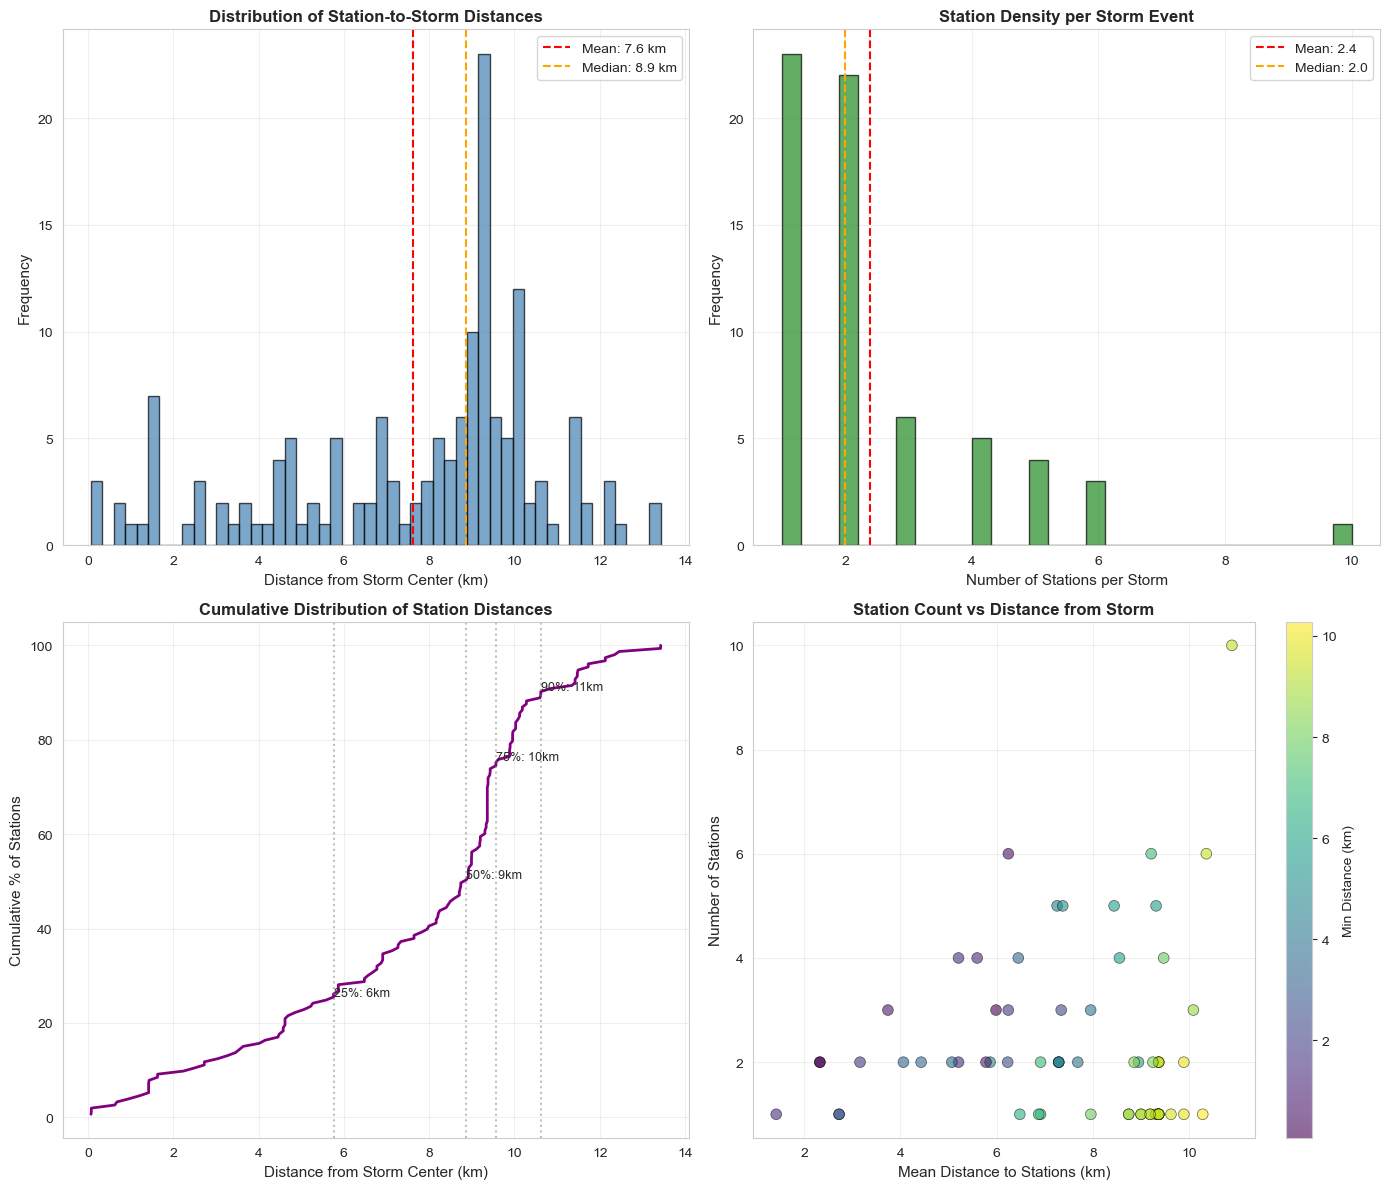


📊 Visualization generated successfully!


In [20]:
# Visualize spatial coverage patterns
if len(df_spatial) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Distance distribution
    ax = axes[0, 0]
    ax.hist(df_spatial['distance_km'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(df_spatial['distance_km'].mean(), color='red', linestyle='--', 
               label=f'Mean: {df_spatial["distance_km"].mean():.1f} km')
    ax.axvline(df_spatial['distance_km'].median(), color='orange', linestyle='--',
               label=f'Median: {df_spatial["distance_km"].median():.1f} km')
    ax.set_xlabel('Distance from Storm Center (km)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Distribution of Station-to-Storm Distances', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Number of stations per storm
    ax = axes[0, 1]
    stations_per_storm = df_spatial.groupby('storm_id').size()
    ax.hist(stations_per_storm, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
    ax.axvline(stations_per_storm.mean(), color='red', linestyle='--',
               label=f'Mean: {stations_per_storm.mean():.1f}')
    ax.axvline(stations_per_storm.median(), color='orange', linestyle='--',
               label=f'Median: {stations_per_storm.median():.1f}')
    ax.set_xlabel('Number of Stations per Storm', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Station Density per Storm Event', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Cumulative distribution of distances
    ax = axes[1, 0]
    sorted_distances = np.sort(df_spatial['distance_km'])
    cumulative = np.arange(1, len(sorted_distances) + 1) / len(sorted_distances) * 100
    ax.plot(sorted_distances, cumulative, color='purple', linewidth=2)
    
    # Mark key percentiles
    for pct in [25, 50, 75, 90]:
        dist_at_pct = np.percentile(df_spatial['distance_km'], pct)
        ax.axvline(dist_at_pct, color='gray', linestyle=':', alpha=0.5)
        ax.text(dist_at_pct, pct, f'{pct}%: {dist_at_pct:.0f}km', 
                fontsize=9, ha='left', va='bottom')
    
    ax.set_xlabel('Distance from Storm Center (km)', fontsize=11)
    ax.set_ylabel('Cumulative % of Stations', fontsize=11)
    ax.set_title('Cumulative Distribution of Station Distances', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 4. Distance vs number of stations (scatter)
    ax = axes[1, 1]
    storm_stats = df_spatial.groupby('storm_id').agg({
        'distance_km': ['mean', 'min'],
        'station_id': 'count'
    }).reset_index()
    storm_stats.columns = ['storm_id', 'mean_distance', 'min_distance', 'num_stations']
    
    scatter = ax.scatter(storm_stats['mean_distance'], storm_stats['num_stations'],
                        c=storm_stats['min_distance'], cmap='viridis',
                        s=60, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Mean Distance to Stations (km)', fontsize=11)
    ax.set_ylabel('Number of Stations', fontsize=11)
    ax.set_title('Station Count vs Distance from Storm', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Min Distance (km)', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Visualization generated successfully!")
else:
    print("⚠️  No spatial data available for visualization")

In [21]:
# Analyze spatial coverage quality and provide recommendations
if len(df_spatial) > 0:
    print("=" * 70)
    print("SPATIAL COVERAGE ANALYSIS - KEY FINDINGS")
    print("=" * 70)
    
    # Calculate statistics
    mean_dist = df_spatial['distance_km'].mean()
    median_dist = df_spatial['distance_km'].median()
    p25_dist = df_spatial['distance_km'].quantile(0.25)
    p75_dist = df_spatial['distance_km'].quantile(0.75)
    p90_dist = df_spatial['distance_km'].quantile(0.90)
    
    stations_per_storm = df_spatial.groupby('storm_id').size()
    mean_stations = stations_per_storm.mean()
    median_stations = stations_per_storm.median()
    min_stations = stations_per_storm.min()
    max_stations = stations_per_storm.max()
    
    # Find closest and farthest stations
    closest_dist = df_spatial['distance_km'].min()
    farthest_dist = df_spatial['distance_km'].max()
    
    # Count how many stations within common distance thresholds
    within_10km = (df_spatial['distance_km'] <= 10).sum()
    within_25km = (df_spatial['distance_km'] <= 25).sum()
    within_50km = (df_spatial['distance_km'] <= 50).sum()
    within_100km = (df_spatial['distance_km'] <= 100).sum()
    
    total_pairs = len(df_spatial)
    
    print(f"\n1. DISTANCE STATISTICS:")
    print(f"   • Mean distance: {mean_dist:.1f} km")
    print(f"   • Median distance: {median_dist:.1f} km")
    print(f"   • 25th percentile: {p25_dist:.1f} km")
    print(f"   • 75th percentile: {p75_dist:.1f} km")
    print(f"   • 90th percentile: {p90_dist:.1f} km")
    print(f"   • Range: {closest_dist:.1f} - {farthest_dist:.1f} km")
    
    print(f"\n2. STATION COVERAGE:")
    print(f"   • Stations within 10 km: {within_10km} ({within_10km/total_pairs*100:.1f}%)")
    print(f"   • Stations within 25 km: {within_25km} ({within_25km/total_pairs*100:.1f}%)")
    print(f"   • Stations within 50 km: {within_50km} ({within_50km/total_pairs*100:.1f}%)")
    print(f"   • Stations within 100 km: {within_100km} ({within_100km/total_pairs*100:.1f}%)")
    
    print(f"\n3. STATION DENSITY:")
    print(f"   • Mean stations per storm: {mean_stations:.1f}")
    print(f"   • Median stations per storm: {median_stations:.1f}")
    print(f"   • Range: {min_stations} - {max_stations} stations")
    
    # Provide recommendations
    print(f"\n" + "=" * 70)
    print("RECOMMENDATIONS")
    print("=" * 70)
    print(f"\n⚠️  NOTE: Data was pre-filtered to 20 km radius during download")
    print(f"   All stations are within 20 km of storm centers by design\n")
    
    recommendations = []
    
    # Distance-based recommendations (accounting for 20km constraint)
    pct_within_10km = within_10km / total_pairs * 100
    recommendations.append(f"✓ EXCELLENT PROXIMITY: Median {median_dist:.1f} km, {pct_within_10km:.1f}% within 10 km")
    recommendations.append(f"   → Stations are very close to storm centers (all within 20 km by design)")
    
    # Station density recommendations
    if mean_stations < 3:
        recommendations.append(f"⚠️  LOW STATION DENSITY: Average {mean_stations:.1f} stations per storm")
        recommendations.append(f"   → Consider expanding search radius beyond 20 km to capture more stations")
        recommendations.append(f"   → Current radius may be too restrictive for comprehensive coverage")
    elif mean_stations < 5:
        recommendations.append(f"⚡ MODERATE DENSITY: Average {mean_stations:.1f} stations per storm")
        recommendations.append(f"   → Sufficient for dual/triple-station averaging")
    else:
        recommendations.append(f"✓ GOOD DENSITY: Average {mean_stations:.1f} stations per storm")
        recommendations.append(f"   → Can use multi-station spatial averaging")
    
    # Weighting strategy recommendation
    if pct_within_10km < 50:
        recommendations.append(f"📍 DISTANCE WEIGHTING RECOMMENDED: Only {pct_within_10km:.1f}% within 10 km")
        recommendations.append("   → Use inverse-distance weighting (1/distance or 1/distance²)")
    else:
        recommendations.append(f"📍 DISTANCE WEIGHTING OPTIONAL: {pct_within_10km:.1f}% within 10 km")
        recommendations.append("   → Stations are close enough that simple averaging may work")
        recommendations.append("   → Consider weighting if using stations >10 km away")
    
    # Data integration strategy based on actual density
    if mean_stations >= 3:
        recommendations.append("🔄 MULTI-STATION STRATEGY: Use all available stations with distance weighting")
        recommendations.append("   → Weight by inverse distance: w_i = 1/d_i or 1/d_i²")
        recommendations.append("   → Or use nearest K=3 stations only")
    elif mean_stations >= 2:
        recommendations.append("🔄 DUAL-STATION STRATEGY: Average 2 nearest stations")
        recommendations.append("   → Optional: Apply distance weighting if distances vary significantly")
    else:
        recommendations.append("🔄 SINGLE-STATION: Use nearest station only")
        recommendations.append("   → Consider increasing search radius to get more stations")
    
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{i}. {rec}")
    
    # Final summary
    print(f"\n" + "=" * 70)
    print("NEXT STEPS FOR CNN INTEGRATION")
    print("=" * 70)
    print()
    print("Given the 20 km search radius constraint and current coverage:")
    print()
    print("  1. DATA AGGREGATION STRATEGY:")
    print(f"     • Use all available stations per storm (avg {mean_stations:.1f} stations)")
    print("     • Apply inverse-distance weighting: feature_weighted = Σ(f_i / d_i) / Σ(1 / d_i)")
    print("     • Alternative: Use K=2 nearest stations only for consistency")
    print()
    print("  2. FEATURE ENGINEERING:")
    print(f"     • Add 'min_station_distance' as auxiliary input (range: {closest_dist:.1f}-{farthest_dist:.1f} km)")
    print("     • Add 'num_stations_available' as coverage indicator")
    print("     • Add station distance variance to capture spatial uncertainty")
    print()
    print("  3. SEARCH RADIUS OPTIMIZATION:")
    print(f"     • Current: 20 km radius → avg {mean_stations:.1f} stations per storm")
    print("     • Consider testing 30 km or 40 km radius to improve station density")
    print("     • Trade-off: more stations vs. reduced relevance to local conditions")
    print()
    print("  4. MISSING DATA HANDLING:")
    print("     • Some storms may have 0 stations (if none passed quality filters)")
    print("     • Use mean imputation or 'missing' indicator for storms without MADIS")
    print()
    print("  5. MODEL ARCHITECTURE:")
    print("     • Concatenate distance-weighted MADIS features with CNN features")
    print("     • Consider attention mechanism weighted by distance")
    print("     • Validate that MADIS features improve performance vs. radar-only baseline")
    
else:
    print("⚠️  No spatial data available for analysis")

SPATIAL COVERAGE ANALYSIS - KEY FINDINGS

1. DISTANCE STATISTICS:
   • Mean distance: 7.6 km
   • Median distance: 8.9 km
   • 25th percentile: 5.8 km
   • 75th percentile: 9.6 km
   • 90th percentile: 10.6 km
   • Range: 0.1 - 13.4 km

2. STATION COVERAGE:
   • Stations within 10 km: 125 (81.7%)
   • Stations within 25 km: 153 (100.0%)
   • Stations within 50 km: 153 (100.0%)
   • Stations within 100 km: 153 (100.0%)

3. STATION DENSITY:
   • Mean stations per storm: 2.4
   • Median stations per storm: 2.0
   • Range: 1 - 10 stations

RECOMMENDATIONS

⚠️  NOTE: Data was pre-filtered to 20 km radius during download
   All stations are within 20 km of storm centers by design


1. ✓ EXCELLENT PROXIMITY: Median 8.9 km, 81.7% within 10 km

2.    → Stations are very close to storm centers (all within 20 km by design)

3. ⚠️  LOW STATION DENSITY: Average 2.4 stations per storm

4.    → Consider expanding search radius beyond 20 km to capture more stations

5.    → Current radius may be too r

## 9. Meteorological Predictive Power Analysis 🎯

**Critical Question:** Which MADIS weather variables actually correlate with tornado occurrence and intensity?

This analysis helps us understand:
1. **Feature Discriminability** - Can MADIS variables distinguish tornado from non-tornado events?
2. **Intensity Correlation** - Do stronger tornadoes show different weather signatures?
3. **Variable Importance** - Which of the 7 features are most predictive?

**Approach:**
- Compare feature distributions: Tornado (EF ≥ 0) vs. Non-tornado (EF < 0)
- Calculate correlation coefficients with EF rating
- Identify which variables provide the strongest signal for CNN model

In [22]:
# Analyze meteorological predictive power
print("METEOROLOGICAL PREDICTIVE POWER ANALYSIS")
print("=" * 70)

# Check if we have category information to separate tornado vs non-tornado
if 'category' in df_merged.columns or 'ef_number' in df_merged.columns:
    
    # Separate tornado vs non-tornado events
    if 'ef_number' in df_merged.columns:
        df_tornado = df_merged[df_merged['ef_number'] >= 0].copy()
        df_non_tornado = df_merged[df_merged['ef_number'] < 0].copy()
        
        print(f"\nDataset Overview:")
        print(f"  Tornado events (EF ≥ 0):     {len(df_tornado)} samples")
        print(f"  Non-tornado events (EF < 0): {len(df_non_tornado)} samples")
        
        if len(df_tornado) > 0 and len(df_non_tornado) > 0:
            print(f"  Class balance ratio:         {len(df_tornado) / len(df_non_tornado):.2f}")
        
        # Check which weather variables we have
        weather_vars = ['v_t_mean', 'v_td_mean', 'v_rh_mean', 'v_ff_mean', 
                       'v_dd_mean', 'v_altse_mean', 'v_ffgust_mean']
        available_vars = [v for v in weather_vars if v in df_merged.columns]
        
        print(f"\nAvailable weather variables: {len(available_vars)}")
        for var in available_vars:
            print(f"  - {var}")
            
    else:
        print("\n⚠️  No EF rating column found for analysis")
        available_vars = []
        df_tornado = pd.DataFrame()
        df_non_tornado = pd.DataFrame()
else:
    print("\n⚠️  No category or EF rating information available")
    available_vars = []
    df_tornado = pd.DataFrame()
    df_non_tornado = pd.DataFrame()

METEOROLOGICAL PREDICTIVE POWER ANALYSIS

Dataset Overview:
  Tornado events (EF ≥ 0):     363 samples
  Non-tornado events (EF < 0): 17106 samples
  Class balance ratio:         0.02

Available weather variables: 7
  - v_t_mean
  - v_td_mean
  - v_rh_mean
  - v_ff_mean
  - v_dd_mean
  - v_altse_mean
  - v_ffgust_mean


In [23]:
# Compare distributions between tornado and non-tornado events
if len(df_tornado) > 0 and len(df_non_tornado) > 0 and len(available_vars) > 0:
    
    print("\n" + "=" * 70)
    print("STATISTICAL COMPARISON: TORNADO vs NON-TORNADO")
    print("=" * 70)
    
    comparison_results = []
    
    for var in available_vars:
        # Get data for both groups
        tornado_vals = df_tornado[var].dropna()
        non_tornado_vals = df_non_tornado[var].dropna()
        
        if len(tornado_vals) > 0 and len(non_tornado_vals) > 0:
            # Calculate statistics
            from scipy import stats
            
            # T-test to check if means are significantly different
            t_stat, p_value = stats.ttest_ind(tornado_vals, non_tornado_vals)
            
            # Effect size (Cohen's d)
            pooled_std = np.sqrt((tornado_vals.std()**2 + non_tornado_vals.std()**2) / 2)
            cohens_d = (tornado_vals.mean() - non_tornado_vals.mean()) / pooled_std if pooled_std > 0 else 0
            
            comparison_results.append({
                'variable': var,
                'tornado_mean': tornado_vals.mean(),
                'tornado_std': tornado_vals.std(),
                'non_tornado_mean': non_tornado_vals.mean(),
                'non_tornado_std': non_tornado_vals.std(),
                'mean_difference': tornado_vals.mean() - non_tornado_vals.mean(),
                'cohens_d': cohens_d,
                'p_value': p_value,
                'significant': p_value < 0.05
            })
    
    # Create comparison DataFrame
    df_comparison = pd.DataFrame(comparison_results)
    
    # Sort by absolute effect size (Cohen's d)
    df_comparison['abs_cohens_d'] = df_comparison['cohens_d'].abs()
    df_comparison = df_comparison.sort_values('abs_cohens_d', ascending=False)
    
    print("\nStatistical Tests (sorted by effect size):")
    print("-" * 70)
    for idx, row in df_comparison.iterrows():
        sig_marker = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
        print(f"\n{row['variable']}:")
        print(f"  Tornado:     {row['tornado_mean']:>10.2f} ± {row['tornado_std']:.2f}")
        print(f"  Non-tornado: {row['non_tornado_mean']:>10.2f} ± {row['non_tornado_std']:.2f}")
        print(f"  Difference:  {row['mean_difference']:>10.2f}")
        print(f"  Cohen's d:   {row['cohens_d']:>10.3f}")
        print(f"  p-value:     {row['p_value']:>10.4f} {sig_marker}")
    
    print("\n" + "=" * 70)
    print("Effect Size Interpretation (Cohen's d):")
    print("  |d| < 0.2:  Negligible difference")
    print("  |d| ≥ 0.2:  Small effect")
    print("  |d| ≥ 0.5:  Medium effect")
    print("  |d| ≥ 0.8:  Large effect")
else:
    print("\nInsufficient data for statistical comparison")
    df_comparison = pd.DataFrame()


STATISTICAL COMPARISON: TORNADO vs NON-TORNADO

Statistical Tests (sorted by effect size):
----------------------------------------------------------------------

v_altse_mean:
  Tornado:      100014.76 ± 780.12
  Non-tornado:  100852.83 ± 501.12
  Difference:     -838.07
  Cohen's d:       -1.278
  p-value:         0.0000 ***

v_ff_mean:
  Tornado:           2.73 ± 2.17
  Non-tornado:       1.60 ± 1.54
  Difference:        1.12
  Cohen's d:        0.596
  p-value:         0.0000 ***

v_ffgust_mean:
  Tornado:           5.86 ± 3.62
  Non-tornado:       4.29 ± 3.33
  Difference:        1.58
  Cohen's d:        0.452
  p-value:         0.0000 ***

v_dd_mean:
  Tornado:         174.49 ± 62.34
  Non-tornado:     186.33 ± 75.34
  Difference:      -11.84
  Cohen's d:       -0.171
  p-value:         0.0036 **

v_t_mean:
  Tornado:         293.45 ± 3.58
  Non-tornado:     294.25 ± 5.76
  Difference:       -0.79
  Cohen's d:       -0.166
  p-value:         0.0092 **

v_rh_mean:
  Tornado:     

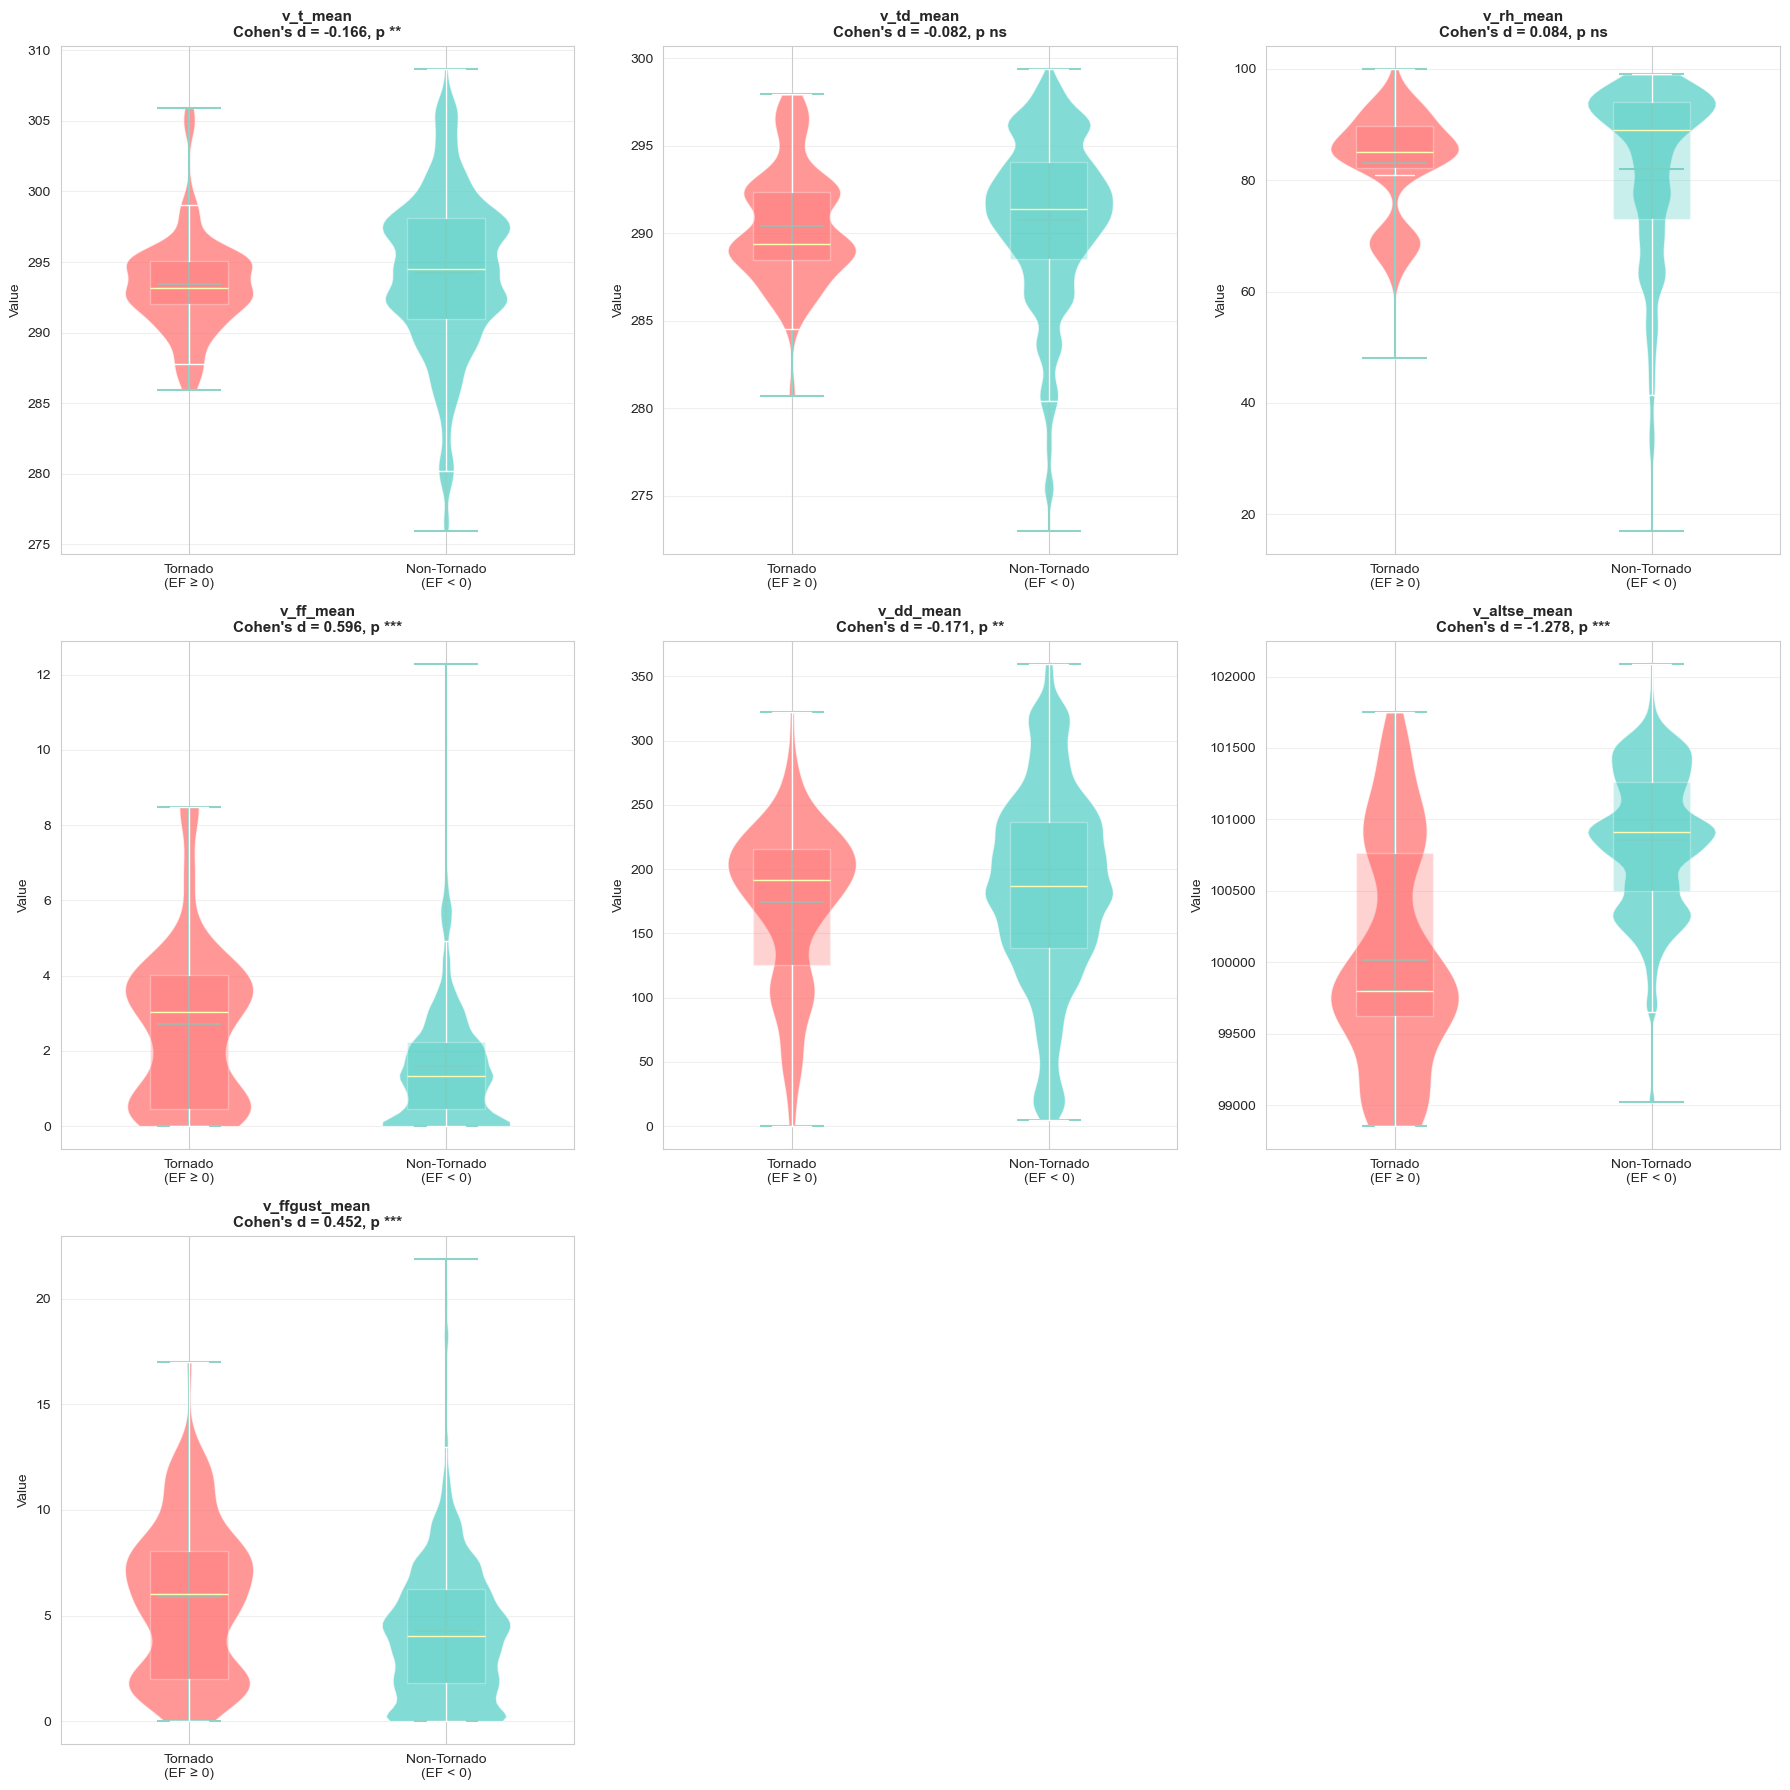


📊 Distribution comparison complete!


In [24]:
# Visualize distributions: Tornado vs Non-Tornado
if len(df_tornado) > 0 and len(df_non_tornado) > 0 and len(available_vars) > 0:
    
    # Create violin plots comparing distributions
    n_vars = len(available_vars)
    n_rows = (n_vars + 2) // 3  # 3 plots per row
    n_cols = min(3, n_vars)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
    if n_vars == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, var in enumerate(available_vars):
        ax = axes[idx]
        
        # Prepare data for violin plot
        tornado_data = df_tornado[var].dropna()
        non_tornado_data = df_non_tornado[var].dropna()
        
        # Create violin plot
        parts = ax.violinplot([tornado_data, non_tornado_data], 
                              positions=[1, 2],
                              showmeans=True, 
                              showmedians=True)
        
        # Color the violins
        for pc, color in zip(parts['bodies'], ['#ff6b6b', '#4ecdc4']):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        
        # Add box plots on top for quartile info
        bp = ax.boxplot([tornado_data, non_tornado_data],
                        positions=[1, 2],
                        widths=0.3,
                        patch_artist=True,
                        showfliers=False)
        
        for patch, color in zip(bp['boxes'], ['#ff6b6b', '#4ecdc4']):
            patch.set_facecolor(color)
            patch.set_alpha(0.3)
        
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Tornado\n(EF ≥ 0)', 'Non-Tornado\n(EF < 0)'])
        ax.set_ylabel('Value')
        
        # Add variable name and statistics
        if var in df_comparison['variable'].values:
            stats_row = df_comparison[df_comparison['variable'] == var].iloc[0]
            cohens_d = stats_row['cohens_d']
            p_val = stats_row['p_value']
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            
            ax.set_title(f"{var}\nCohen's d = {cohens_d:.3f}, p {sig}", 
                        fontsize=11, fontweight='bold')
        else:
            ax.set_title(var, fontsize=11, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
    
    # Hide unused subplots
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Distribution comparison complete!")
else:
    print("Skipping visualization - insufficient data")


CORRELATION WITH TORNADO INTENSITY (EF RATING)

Correlations with EF Rating (sorted by strength):
----------------------------------------------------------------------

v_ff_mean:
  Pearson r:    0.669 (p=0.0000) ***
  Spearman r:   0.676 (p=0.0000)
  Samples:    348

v_ffgust_mean:
  Pearson r:    0.636 (p=0.0000) ***
  Spearman r:   0.661 (p=0.0000)
  Samples:    363

v_dd_mean:
  Pearson r:    0.401 (p=0.0000) ***
  Spearman r:   0.420 (p=0.0000)
  Samples:    348

v_altse_mean:
  Pearson r:   -0.287 (p=0.0000) ***
  Spearman r:  -0.252 (p=0.0000)
  Samples:    294

v_td_mean:
  Pearson r:   -0.184 (p=0.0006) ***
  Spearman r:  -0.230 (p=0.0000)
  Samples:    340

v_t_mean:
  Pearson r:   -0.132 (p=0.0124) *
  Spearman r:  -0.147 (p=0.0053)
  Samples:    359

v_rh_mean:
  Pearson r:   -0.088 (p=0.1062) 
  Spearman r:  -0.146 (p=0.0070)
  Samples:    340


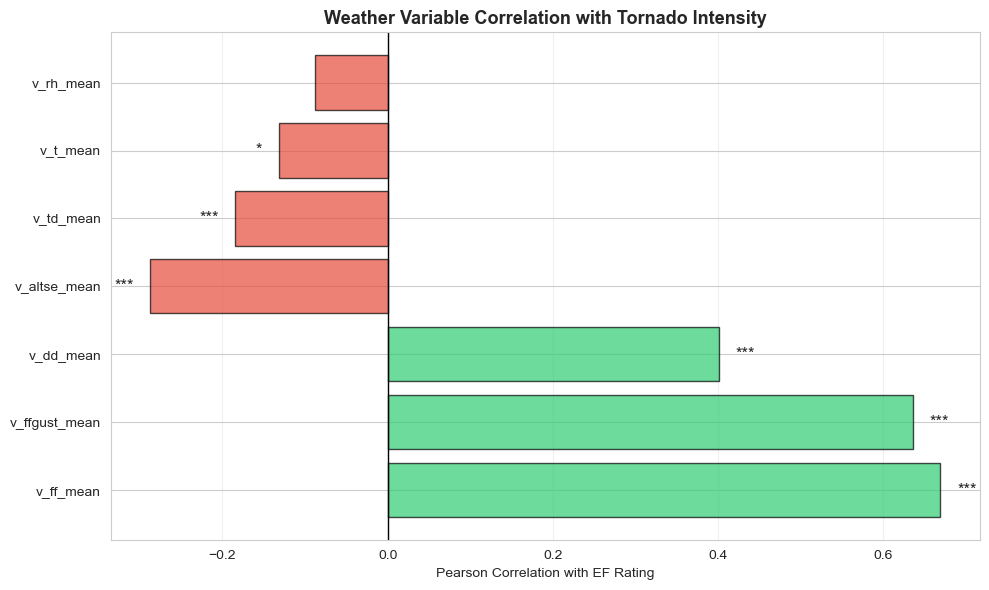

In [25]:
# Correlation with EF rating (for tornado events only)
if len(df_tornado) > 0 and 'ef_number' in df_tornado.columns and len(available_vars) > 0:
    
    print("\n" + "=" * 70)
    print("CORRELATION WITH TORNADO INTENSITY (EF RATING)")
    print("=" * 70)
    
    # Calculate correlations
    correlations = []
    
    for var in available_vars:
        valid_data = df_tornado[[var, 'ef_number']].dropna()
        
        if len(valid_data) > 10:  # Need sufficient data
            # Pearson correlation
            pearson_corr, pearson_p = stats.pearsonr(valid_data[var], valid_data['ef_number'])
            
            # Spearman correlation (non-parametric)
            spearman_corr, spearman_p = stats.spearmanr(valid_data[var], valid_data['ef_number'])
            
            correlations.append({
                'variable': var,
                'pearson_r': pearson_corr,
                'pearson_p': pearson_p,
                'spearman_r': spearman_corr,
                'spearman_p': spearman_p,
                'n_samples': len(valid_data)
            })
    
    df_corr = pd.DataFrame(correlations)
    df_corr['abs_pearson_r'] = df_corr['pearson_r'].abs()
    df_corr = df_corr.sort_values('abs_pearson_r', ascending=False)
    
    print("\nCorrelations with EF Rating (sorted by strength):")
    print("-" * 70)
    
    for idx, row in df_corr.iterrows():
        sig_marker = "***" if row['pearson_p'] < 0.001 else "**" if row['pearson_p'] < 0.01 else "*" if row['pearson_p'] < 0.05 else ""
        
        print(f"\n{row['variable']}:")
        print(f"  Pearson r:  {row['pearson_r']:>7.3f} (p={row['pearson_p']:.4f}) {sig_marker}")
        print(f"  Spearman r: {row['spearman_r']:>7.3f} (p={row['spearman_p']:.4f})")
        print(f"  Samples:    {row['n_samples']}")
    
    # Visualize correlation strengths
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    y_pos = np.arange(len(df_corr))
    colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in df_corr['pearson_r']]
    
    bars = ax.barh(y_pos, df_corr['pearson_r'], color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_corr['variable'])
    ax.set_xlabel('Pearson Correlation with EF Rating')
    ax.set_title('Weather Variable Correlation with Tornado Intensity', fontweight='bold', fontsize=13)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add significance markers
    for i, (idx, row) in enumerate(df_corr.iterrows()):
        sig = "***" if row['pearson_p'] < 0.001 else "**" if row['pearson_p'] < 0.01 else "*" if row['pearson_p'] < 0.05 else ""
        if sig:
            x_pos = row['pearson_r'] + (0.02 if row['pearson_r'] > 0 else -0.02)
            ax.text(x_pos, i, sig, va='center', ha='left' if row['pearson_r'] > 0 else 'right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("\nInsufficient tornado event data for correlation analysis")
    df_corr = pd.DataFrame()

In [26]:
# Summary and Recommendations
print("\n" + "=" * 70)
print("PREDICTIVE POWER SUMMARY & RECOMMENDATIONS")
print("=" * 70)

if len(df_comparison) > 0:
    # Rank variables by discriminative power
    strong_discriminators = df_comparison[df_comparison['abs_cohens_d'] >= 0.5]['variable'].tolist()
    moderate_discriminators = df_comparison[(df_comparison['abs_cohens_d'] >= 0.2) & 
                                           (df_comparison['abs_cohens_d'] < 0.5)]['variable'].tolist()
    weak_discriminators = df_comparison[df_comparison['abs_cohens_d'] < 0.2]['variable'].tolist()
    
    print("\n1. DISCRIMINATIVE POWER (Tornado vs Non-Tornado):")
    print(f"   • Strong (|d| ≥ 0.5):   {len(strong_discriminators)} variables")
    if strong_discriminators:
        print(f"     → {', '.join(strong_discriminators)}")
    print(f"   • Moderate (|d| ≥ 0.2): {len(moderate_discriminators)} variables")
    if moderate_discriminators:
        print(f"     → {', '.join(moderate_discriminators)}")
    print(f"   • Weak (|d| < 0.2):     {len(weak_discriminators)} variables")
    if weak_discriminators:
        print(f"     → {', '.join(weak_discriminators)}")

if len(df_corr) > 0:
    strong_correlates = df_corr[df_corr['abs_pearson_r'] >= 0.3]['variable'].tolist()
    moderate_correlates = df_corr[(df_corr['abs_pearson_r'] >= 0.1) & 
                                  (df_corr['abs_pearson_r'] < 0.3)]['variable'].tolist()
    
    print("\n2. INTENSITY CORRELATION (with EF Rating):")
    print(f"   • Strong (|r| ≥ 0.3):   {len(strong_correlates)} variables")
    if strong_correlates:
        print(f"     → {', '.join(strong_correlates)}")
    print(f"   • Moderate (|r| ≥ 0.1): {len(moderate_correlates)} variables")
    if moderate_correlates:
        print(f"     → {', '.join(moderate_correlates)}")

print("\n3. RECOMMENDATIONS FOR CNN MODEL:")

if len(df_comparison) > 0:
    # Identify top features
    top_features = df_comparison.nlargest(3, 'abs_cohens_d')['variable'].tolist()
    
    if len(strong_discriminators) > 0:
        print("   ✓ MADIS data shows predictive signal - include in CNN model")
        print(f"   ✓ Prioritize these features: {', '.join(top_features[:3])}")
    elif len(moderate_discriminators) > 0:
        print("   ⚡ Moderate signal detected - MADIS may provide marginal improvement")
        print(f"   → Test with features: {', '.join(top_features[:3])}")
    else:
        print("   ⚠️  WEAK SIGNAL: MADIS variables show limited discriminative power")
        print("   → Consider radar-only baseline or feature engineering")
    
    if len(weak_discriminators) >= 4:
        print(f"\n   💡 Consider dropping weak features: {', '.join(weak_discriminators)}")
        print("      → Reduces model complexity without losing predictive power")
    
    print("\n4. FEATURE ENGINEERING SUGGESTIONS:")
    
    # Check for specific patterns
    if 'v_ff_mean' in strong_discriminators or 'v_ffgust_mean' in strong_discriminators:
        print("   • Wind features are strong → add wind shear/gradient features")
    
    if 'v_t_mean' in strong_discriminators and 'v_td_mean' in strong_discriminators:
        print("   • Temperature features matter → compute derived features:")
        print("     - Temperature-dewpoint spread (instability)")
        print("     - Relative humidity from T and Td")
    
    if 'v_altse_mean' in strong_discriminators:
        print("   • Pressure is discriminative → consider pressure gradient")
    
    print("\n5. NEXT STEPS:")
    print("   1. Run ablation study: CNN with vs. without MADIS features")
    print("   2. Test feature subset: use only strong/moderate discriminators")
    print("   3. Implement feature engineering based on patterns above")
    print("   4. Consider ensemble: separate models for strong vs. weak signal regions")

else:
    print("\n⚠️  Analysis could not be completed - check data availability")

print("\n" + "=" * 70)


PREDICTIVE POWER SUMMARY & RECOMMENDATIONS

1. DISCRIMINATIVE POWER (Tornado vs Non-Tornado):
   • Strong (|d| ≥ 0.5):   2 variables
     → v_altse_mean, v_ff_mean
   • Moderate (|d| ≥ 0.2): 1 variables
     → v_ffgust_mean
   • Weak (|d| < 0.2):     4 variables
     → v_dd_mean, v_t_mean, v_rh_mean, v_td_mean

2. INTENSITY CORRELATION (with EF Rating):
   • Strong (|r| ≥ 0.3):   3 variables
     → v_ff_mean, v_ffgust_mean, v_dd_mean
   • Moderate (|r| ≥ 0.1): 3 variables
     → v_altse_mean, v_td_mean, v_t_mean

3. RECOMMENDATIONS FOR CNN MODEL:
   ✓ MADIS data shows predictive signal - include in CNN model
   ✓ Prioritize these features: v_altse_mean, v_ff_mean, v_ffgust_mean

   💡 Consider dropping weak features: v_dd_mean, v_t_mean, v_rh_mean, v_td_mean
      → Reduces model complexity without losing predictive power

4. FEATURE ENGINEERING SUGGESTIONS:
   • Wind features are strong → add wind shear/gradient features
   • Pressure is discriminative → consider pressure gradient

5.

### 9.1 Extreme Value Capture Analysis 🌪️

**Critical Question:** Do MADIS weather stations actually capture extreme conditions during tornado events?

**Challenge:** MADIS personal weather stations typically report only every 30 minutes, which may miss brief but intense tornado conditions.

This analysis examines:
1. **Range Comparison** - Are tornado event values more extreme than non-tornado events?
2. **Sensor Saturation** - Are stations hitting measurement limits during extreme weather?
3. **Outlier Legitimacy** - Were severe weather outliers incorrectly filtered out earlier?
4. **Temporal Sampling** - Does 30-min reporting capture peak conditions?

**Why it matters:** If weather stations miss extreme values, MADIS features may underestimate tornado severity and limit model performance.

In [30]:
# Extreme Value Capture Analysis
print("EXTREME VALUE CAPTURE ANALYSIS")
print("=" * 70)

if 'ef_number' in df_merged.columns and len(available_vars) > 0:
    
    # Separate tornado and non-tornado events
    df_tornado_extreme = df_merged[df_merged['ef_number'] >= 0].copy()
    df_non_tornado_extreme = df_merged[df_merged['ef_number'] < 0].copy()
    
    print(f"\n⚠️  NOTE: MADIS stations typically report every 30 minutes")
    print(f"   Brief extreme conditions may be missed between observations\n")
    
    print("1. EXTREME VALUE RANGES:")
    print("-" * 70)
    
    extreme_analysis = []
    
    for var in available_vars:
        # Get statistics for both groups
        tor_data = df_tornado_extreme[var].dropna()
        non_tor_data = df_non_tornado_extreme[var].dropna()
        
        if len(tor_data) > 0 and len(non_tor_data) > 0:
            extreme_analysis.append({
                'variable': var,
                'tornado_min': tor_data.min(),
                'tornado_max': tor_data.max(),
                'tornado_99th': tor_data.quantile(0.99),
                'tornado_1st': tor_data.quantile(0.01),
                'non_tornado_min': non_tor_data.min(),
                'non_tornado_max': non_tor_data.max(),
                'non_tornado_99th': non_tor_data.quantile(0.99),
                'non_tornado_1st': non_tor_data.quantile(0.01),
                'captures_higher_max': tor_data.max() > non_tor_data.max(),
                'captures_lower_min': tor_data.min() < non_tor_data.min(),
            })
    
    df_extreme = pd.DataFrame(extreme_analysis)
    
    for idx, row in df_extreme.iterrows():
        print(f"\n{row['variable']}:")
        print(f"  Tornado events:")
        print(f"    Min:  {row['tornado_min']:>10.2f}  →  Max: {row['tornado_max']:>10.2f}")
        print(f"    1st%: {row['tornado_1st']:>10.2f}  →  99th%: {row['tornado_99th']:>10.2f}")
        print(f"  Non-tornado events:")
        print(f"    Min:  {row['non_tornado_min']:>10.2f}  →  Max: {row['non_tornado_max']:>10.2f}")
        print(f"    1st%: {row['non_tornado_1st']:>10.2f}  →  99th%: {row['non_tornado_99th']:>10.2f}")
        
        if row['captures_higher_max']:
            print(f"  ✓ Tornado events show MORE EXTREME maximums")
        else:
            print(f"  ⚠️  Non-tornado events have higher maximum values")
            
        if row['captures_lower_min']:
            print(f"  ✓ Tornado events show MORE EXTREME minimums")
        else:
            print(f"  ⚠️  Non-tornado events have lower minimum values")

else:
    print("\n⚠️  Cannot perform extreme value analysis - missing required data")
    df_extreme = pd.DataFrame()

EXTREME VALUE CAPTURE ANALYSIS

⚠️  NOTE: MADIS stations typically report every 30 minutes
   Brief extreme conditions may be missed between observations

1. EXTREME VALUE RANGES:
----------------------------------------------------------------------

v_t_mean:
  Tornado events:
    Min:      285.93  →  Max:     305.93
    1st%:     286.48  →  99th%:     305.05
  Non-tornado events:
    Min:      275.93  →  Max:     308.71
    1st%:     278.71  →  99th%:     306.48
  ⚠️  Non-tornado events have higher maximum values
  ⚠️  Non-tornado events have lower minimum values

v_td_mean:
  Tornado events:
    Min:      280.69  →  Max:     297.93
    1st%:     280.83  →  99th%:     297.67
  Non-tornado events:
    Min:      272.97  →  Max:     299.41
    1st%:     275.45  →  99th%:     298.56
  ⚠️  Non-tornado events have higher maximum values
  ⚠️  Non-tornado events have lower minimum values

v_rh_mean:
  Tornado events:
    Min:       48.00  →  Max:     100.00
    1st%:      63.00  →  99th%:  

In [31]:
# Check for sensor saturation (measurement limits)
if len(df_extreme) > 0:
    
    print("\n" + "=" * 70)
    print("2. SENSOR SATURATION DETECTION:")
    print("=" * 70)
    print("\nChecking if measurements are hitting physical/sensor limits...")
    
    # Define known physical and typical sensor limits
    sensor_limits = {
        'v_t_mean': {'lower': 233.15, 'upper': 323.15, 'name': 'Temperature (K)', 'typical_range': '~233-323 K'},
        'v_td_mean': {'lower': 233.15, 'upper': 323.15, 'name': 'Dewpoint (K)', 'typical_range': '~233-323 K'},
        'v_rh_mean': {'lower': 0, 'upper': 100, 'name': 'Relative Humidity (%)', 'typical_range': '0-100%'},
        'v_ff_mean': {'lower': 0, 'upper': 50, 'name': 'Wind Speed (m/s)', 'typical_range': '0-50 m/s'},
        'v_ffgust_mean': {'lower': 0, 'upper': 60, 'name': 'Wind Gust (m/s)', 'typical_range': '0-60 m/s'},
        'v_dd_mean': {'lower': 0, 'upper': 360, 'name': 'Wind Direction (deg)', 'typical_range': '0-360°'},
        'v_altse_mean': {'lower': 90000, 'upper': 110000, 'name': 'Pressure (Pa)', 'typical_range': '~90000-110000 Pa'}
    }
    
    saturation_found = False
    
    for var in available_vars:
        if var in sensor_limits:
            limits = sensor_limits[var]
            
            # Check tornado events
            tor_data = df_tornado_extreme[var].dropna()
            
            if len(tor_data) > 0:
                # Count values at or very near limits (within 1%)
                lower_limit = limits['lower']
                upper_limit = limits['upper']
                range_width = upper_limit - lower_limit
                tolerance = range_width * 0.01  # 1% tolerance
                
                at_lower_limit = ((tor_data - lower_limit).abs() <= tolerance).sum()
                at_upper_limit = ((tor_data - upper_limit).abs() <= tolerance).sum()
                
                pct_at_lower = (at_lower_limit / len(tor_data)) * 100
                pct_at_upper = (at_upper_limit / len(tor_data)) * 100
                
                if pct_at_lower > 1 or pct_at_upper > 1:
                    saturation_found = True
                    print(f"\n⚠️  {limits['name']} - SATURATION DETECTED:")
                    print(f"    Range: {limits['typical_range']}")
                    if pct_at_lower > 1:
                        print(f"    At lower limit: {at_lower_limit} samples ({pct_at_lower:.1f}%)")
                    if pct_at_upper > 1:
                        print(f"    At upper limit: {at_upper_limit} samples ({pct_at_upper:.1f}%)")
                    print(f"    → May be missing true extreme values during tornadoes")
    
    if not saturation_found:
        print("\n✓ No significant sensor saturation detected")
        print("  Measurements appear to be within normal operating ranges")
        print("  Stations are likely capturing the full range of conditions")

else:
    print("\nCannot check sensor saturation - insufficient data")


2. SENSOR SATURATION DETECTION:

Checking if measurements are hitting physical/sensor limits...

⚠️  Relative Humidity (%) - SATURATION DETECTED:
    Range: 0-100%
    At upper limit: 4 samples (1.2%)
    → May be missing true extreme values during tornadoes

⚠️  Wind Speed (m/s) - SATURATION DETECTED:
    Range: 0-50 m/s
    At lower limit: 88 samples (25.3%)
    → May be missing true extreme values during tornadoes

⚠️  Wind Gust (m/s) - SATURATION DETECTED:
    Range: 0-60 m/s
    At lower limit: 12 samples (3.3%)
    → May be missing true extreme values during tornadoes


In [32]:
# Re-examine outliers from earlier analysis
print("\n" + "=" * 70)
print("3. OUTLIER RE-EXAMINATION:")
print("=" * 70)
print("\nRevisiting outliers removed in Section 6...")

# Check if we still have the outliers DataFrame from earlier
if 'df_outliers' in dir() and len(df_outliers) > 0:
    print(f"\nOutlier summary from earlier analysis:")
    print(df_outliers[['variable', 'n_outliers', 'pct_outliers']].to_string(index=False))
    
    # For each variable, check how many outliers were from tornado events
    print("\n" + "-" * 70)
    print("Outlier composition by storm type:")
    print("-" * 70)
    
    if 'ef_number' in df_merged.columns:
        for var in existing_key_vars[:3]:  # Check first 3 key variables
            if var in df_merged.columns:
                data = df_merged[var].dropna()
                
                # Recalculate outliers
                from scipy import stats
                Q1 = data.quantile(0.25)
                Q3 = data.quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 3 * IQR
                upper_bound = Q3 + 3 * IQR
                
                # Identify outliers
                outlier_mask = (data < lower_bound) | (data > upper_bound)
                outlier_indices = outlier_mask[outlier_mask].index
                
                if len(outlier_indices) > 0:
                    # Check storm types for outliers
                    outlier_storms = df_merged.loc[outlier_indices]
                    tornado_outliers = (outlier_storms['ef_number'] >= 0).sum()
                    non_tornado_outliers = (outlier_storms['ef_number'] < 0).sum()
                    
                    print(f"\n{var}:")
                    print(f"  Total outliers: {len(outlier_indices)}")
                    print(f"  From tornado events:     {tornado_outliers} ({tornado_outliers/len(outlier_indices)*100:.1f}%)")
                    print(f"  From non-tornado events: {non_tornado_outliers} ({non_tornado_outliers/len(outlier_indices)*100:.1f}%)")
                    
                    if tornado_outliers > non_tornado_outliers:
                        print(f"  ⚠️  CAUTION: Outliers are predominantly from tornado events!")
                        print(f"      → These may be legitimate extreme conditions, not errors")
                        print(f"      → Removing them could HARM model performance")
                    else:
                        print(f"  ✓ Outliers are mostly from non-tornado events")
                        print(f"    → Likely measurement errors or anomalies")
    
else:
    print("\n⚠️  Outlier data from Section 6 not available for re-examination")
    print("   Run the outlier detection cells in Section 6 first")


3. OUTLIER RE-EXAMINATION:

Revisiting outliers removed in Section 6...

Outlier summary from earlier analysis:
     variable  n_outliers  pct_outliers
     v_t_mean           0      0.000000
    v_td_mean           0      0.000000
    v_rh_mean           0      0.000000
    v_ff_mean          11      0.553877
    v_dd_mean           0      0.000000
 v_altse_mean           0      0.000000
v_ffgust_mean           5      0.251636

----------------------------------------------------------------------
Outlier composition by storm type:
----------------------------------------------------------------------



VISUALIZATION: Extreme Value Distributions


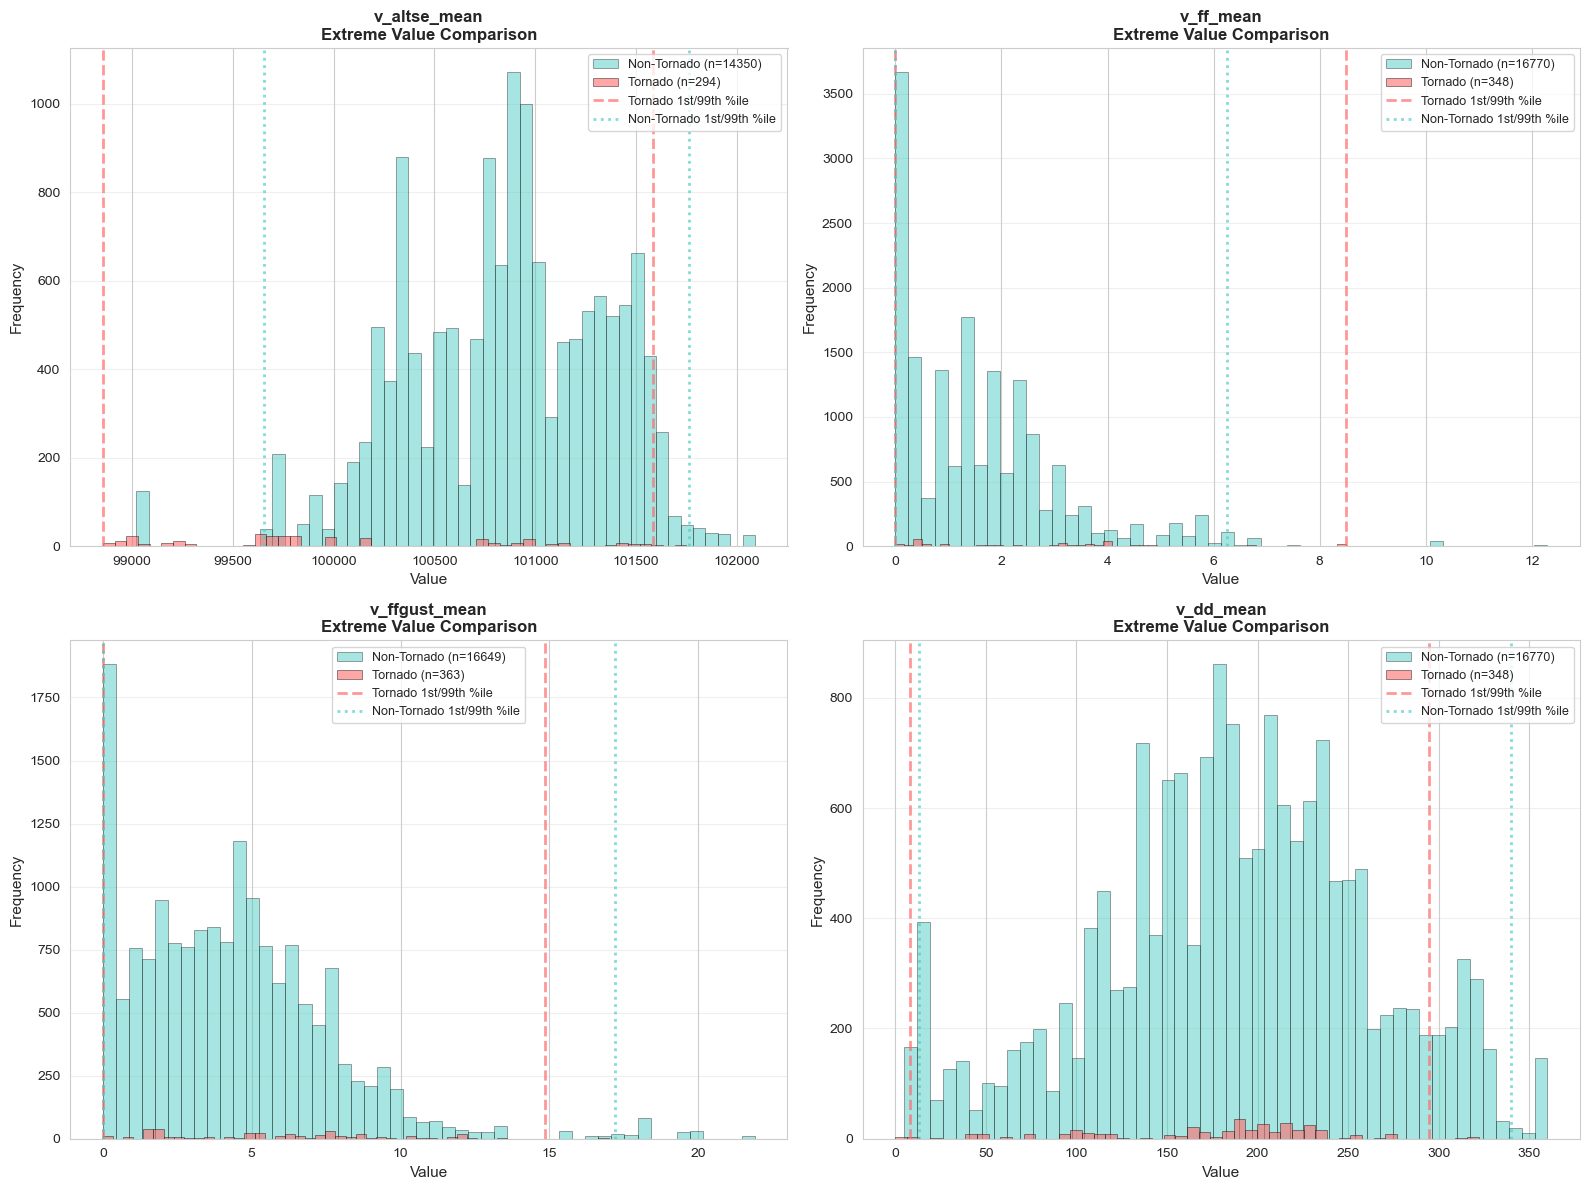


📊 Extreme value visualization complete!
   Dashed lines show 1st and 99th percentiles
   Wide separation suggests good extreme value capture


In [33]:
# Visualize extreme value capture
if len(df_extreme) > 0 and len(df_tornado_extreme) > 0:
    
    print("\n" + "=" * 70)
    print("VISUALIZATION: Extreme Value Distributions")
    print("=" * 70)
    
    # Focus on the strong discriminators identified earlier
    if len(df_comparison) > 0:
        top_vars = df_comparison.nlargest(4, 'abs_cohens_d')['variable'].tolist()
    else:
        top_vars = available_vars[:4]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, var in enumerate(top_vars[:4]):
        ax = axes[idx]
        
        # Get data
        tor_data = df_tornado_extreme[var].dropna()
        non_tor_data = df_non_tornado_extreme[var].dropna()
        
        # Create detailed histograms to show tails
        bins = 50
        
        # Plot histograms
        ax.hist(non_tor_data, bins=bins, alpha=0.5, color='#4ecdc4', 
                label=f'Non-Tornado (n={len(non_tor_data)})', edgecolor='black', linewidth=0.5)
        ax.hist(tor_data, bins=bins, alpha=0.6, color='#ff6b6b', 
                label=f'Tornado (n={len(tor_data)})', edgecolor='black', linewidth=0.5)
        
        # Mark extremes
        ax.axvline(tor_data.quantile(0.01), color='#ff6b6b', linestyle='--', 
                   linewidth=2, alpha=0.7, label='Tornado 1st/99th %ile')
        ax.axvline(tor_data.quantile(0.99), color='#ff6b6b', linestyle='--', 
                   linewidth=2, alpha=0.7)
        
        ax.axvline(non_tor_data.quantile(0.01), color='#4ecdc4', linestyle=':', 
                   linewidth=2, alpha=0.7, label='Non-Tornado 1st/99th %ile')
        ax.axvline(non_tor_data.quantile(0.99), color='#4ecdc4', linestyle=':', 
                   linewidth=2, alpha=0.7)
        
        ax.set_xlabel('Value', fontsize=11)
        ax.set_ylabel('Frequency', fontsize=11)
        ax.set_title(f'{var}\nExtreme Value Comparison', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Extreme value visualization complete!")
    print("   Dashed lines show 1st and 99th percentiles")
    print("   Wide separation suggests good extreme value capture")

In [34]:
# Summary and recommendations
print("\n" + "=" * 70)
print("EXTREME VALUE CAPTURE SUMMARY")
print("=" * 70)

if len(df_extreme) > 0:
    
    # Count variables with good extreme capture
    captures_extremes = df_extreme['captures_higher_max'].sum()
    total_vars = len(df_extreme)
    
    print(f"\n1. EXTREME VALUE CAPTURE:")
    print(f"   Variables showing more extreme values in tornado events: {captures_extremes}/{total_vars}")
    
    if captures_extremes >= total_vars * 0.7:
        print("   ✓ GOOD: Most variables capture more extreme values during tornadoes")
    elif captures_extremes >= total_vars * 0.4:
        print("   ⚡ MODERATE: Some variables capture extremes, others don't")
    else:
        print("   ⚠️  POOR: Most variables do NOT show more extreme values in tornadoes")
        print("       → 30-min sampling may be missing peak conditions")
    
    print("\n2. KEY FINDINGS:")
    
    # Identify best extreme capturers
    best_extreme_vars = df_extreme[df_extreme['captures_higher_max']]['variable'].tolist()
    if best_extreme_vars:
        print(f"   • Best extreme value capture: {', '.join(best_extreme_vars)}")
    
    poor_extreme_vars = df_extreme[~df_extreme['captures_higher_max']]['variable'].tolist()
    if poor_extreme_vars:
        print(f"   • Poor extreme value capture: {', '.join(poor_extreme_vars)}")
        print(f"     → These may be less useful for detecting severe tornadoes")
    
    print("\n3. TEMPORAL SAMPLING LIMITATION:")
    print("   ⚠️  30-minute MADIS reporting interval may miss:")
    print("      • Brief but intense wind gusts")
    print("      • Rapid pressure drops")
    print("      • Short-lived EF0-EF1 tornadoes (avg duration ~4-8 minutes)")
    print("   ✓  More likely to capture:")
    print("      • Longer-duration EF2+ tornadoes")
    print("      • Sustained environmental conditions")
    print("      • Pre-tornado atmospheric state")
    
    print("\n4. RECOMMENDATIONS:")
    
    if captures_extremes >= total_vars * 0.6:
        print("   ✓ MADIS stations DO capture extreme tornado conditions")
        print("   → Include MADIS features in CNN model")
        print("   → Focus on variables with good extreme capture:")
        for var in best_extreme_vars[:3]:
            print(f"      • {var}")
    else:
        print("   ⚠️  Limited extreme value capture detected")
        print("   → MADIS may be more useful for environmental context than peak conditions")
        print("   → Consider weighting by EF rating (longer tornadoes → better capture)")
    
    print("\n5. DATA QUALITY RECOMMENDATIONS:")
    print("   • Do NOT aggressively filter outliers from tornado events")
    print("   • Extreme values during tornadoes are likely legitimate")
    print("   • Use robust normalization (e.g., quantile-based) to handle extremes")
    print("   • Consider separate preprocessing for tornado vs non-tornado samples")

else:
    print("\n⚠️  Analysis could not be completed")

print("\n" + "=" * 70)


EXTREME VALUE CAPTURE SUMMARY

1. EXTREME VALUE CAPTURE:
   Variables showing more extreme values in tornado events: 1/7
   ⚠️  POOR: Most variables do NOT show more extreme values in tornadoes
       → 30-min sampling may be missing peak conditions

2. KEY FINDINGS:
   • Best extreme value capture: v_rh_mean
   • Poor extreme value capture: v_t_mean, v_td_mean, v_ff_mean, v_dd_mean, v_altse_mean, v_ffgust_mean
     → These may be less useful for detecting severe tornadoes

3. TEMPORAL SAMPLING LIMITATION:
   ⚠️  30-minute MADIS reporting interval may miss:
      • Brief but intense wind gusts
      • Rapid pressure drops
      • Short-lived EF0-EF1 tornadoes (avg duration ~4-8 minutes)
   ✓  More likely to capture:
      • Longer-duration EF2+ tornadoes
      • Sustained environmental conditions
      • Pre-tornado atmospheric state

4. RECOMMENDATIONS:
   ⚠️  Limited extreme value capture detected
   → MADIS may be more useful for environmental context than peak conditions
   → Cons

### 9.2 Inter-Feature Correlation Analysis 🔗

**Critical Question:** Are MADIS variables redundant with each other, or do they provide independent information?

This analysis helps us:
1. **Identify Redundancy** - Which features are highly correlated (r > 0.7)?
2. **Optimize Feature Set** - Can we reduce from 7 features to fewer without losing information?
3. **Avoid Multicollinearity** - Highly correlated features can hurt model training
4. **Guide Feature Selection** - Keep orthogonal features that capture different aspects of the storm

**Approach:**
- Compute Pearson correlation matrix for all 7 MADIS variables
- Identify redundant feature pairs
- Perform PCA to see effective dimensionality
- Provide recommendations for minimal feature set

In [38]:
# Correlation Matrix Analysis
print("INTER-FEATURE CORRELATION ANALYSIS")
print("=" * 70)

if len(available_vars) > 1:
    
    # Extract weather variable data
    weather_data = df_merged[available_vars].copy()
    
    # Calculate correlation matrix
    corr_matrix = weather_data.corr(method='pearson')
    
    print(f"\nAnalyzing {len(available_vars)} weather variables...")
    print(f"Total samples: {len(weather_data)}")
    
    # Display correlation matrix
    print("\n" + "=" * 70)
    print("CORRELATION MATRIX (Pearson r):")
    print("=" * 70)
    print(corr_matrix.round(3).to_string())
    
else:
    print("\n⚠️  Insufficient variables for correlation analysis")
    corr_matrix = pd.DataFrame()

INTER-FEATURE CORRELATION ANALYSIS

Analyzing 7 weather variables...
Total samples: 18026

CORRELATION MATRIX (Pearson r):
               v_t_mean  v_td_mean  v_rh_mean  v_ff_mean  v_dd_mean  v_altse_mean  v_ffgust_mean
v_t_mean          1.000      0.713     -0.488     -0.122     -0.009         0.279         -0.079
v_td_mean         0.713      1.000      0.221     -0.245     -0.007         0.266         -0.263
v_rh_mean        -0.488      0.221      1.000     -0.217     -0.018        -0.088         -0.271
v_ff_mean        -0.122     -0.245     -0.217      1.000      0.094        -0.292          0.840
v_dd_mean        -0.009     -0.007     -0.018      0.094      1.000        -0.174          0.146
v_altse_mean      0.279      0.266     -0.088     -0.292     -0.174         1.000         -0.389
v_ffgust_mean    -0.079     -0.263     -0.271      0.840      0.146        -0.389          1.000


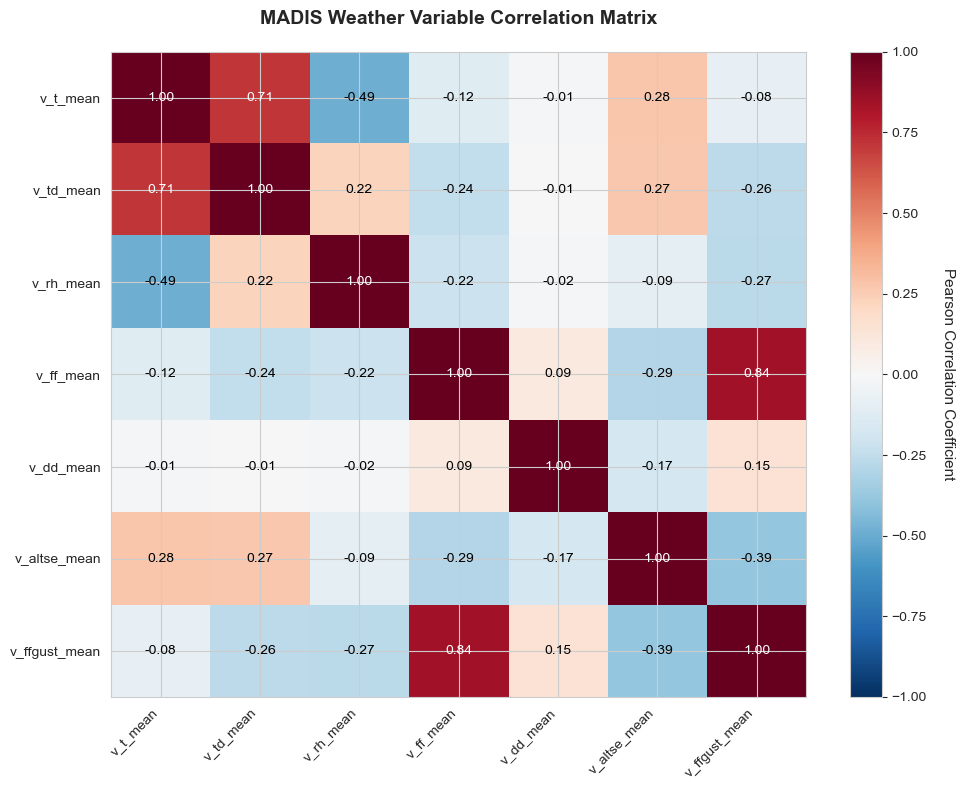


📊 Correlation heatmap generated!
   Red = positive correlation, Blue = negative correlation
   Darker colors = stronger correlation


In [39]:
# Visualize correlation matrix as heatmap
if len(corr_matrix) > 0:
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create heatmap
    import matplotlib.patches as mpatches
    
    im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(available_vars)))
    ax.set_yticks(np.arange(len(available_vars)))
    ax.set_xticklabels(available_vars, rotation=45, ha='right')
    ax.set_yticklabels(available_vars)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Pearson Correlation Coefficient', rotation=270, labelpad=20, fontsize=11)
    
    # Add correlation values as text
    for i in range(len(available_vars)):
        for j in range(len(available_vars)):
            corr_val = corr_matrix.iloc[i, j]
            # Color text based on background
            text_color = 'white' if abs(corr_val) > 0.5 else 'black'
            text = ax.text(j, i, f'{corr_val:.2f}',
                          ha="center", va="center", color=text_color, fontsize=10)
    
    ax.set_title('MADIS Weather Variable Correlation Matrix', 
                fontweight='bold', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Correlation heatmap generated!")
    print("   Red = positive correlation, Blue = negative correlation")
    print("   Darker colors = stronger correlation")

In [40]:
# Identify highly correlated pairs
if len(corr_matrix) > 0:
    
    print("\n" + "=" * 70)
    print("HIGHLY CORRELATED VARIABLE PAIRS:")
    print("=" * 70)
    
    # Find pairs with |r| > threshold
    high_corr_pairs = []
    
    for i in range(len(available_vars)):
        for j in range(i+1, len(available_vars)):  # Upper triangle only
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:  # Threshold for "high" correlation
                high_corr_pairs.append({
                    'var1': available_vars[i],
                    'var2': available_vars[j],
                    'correlation': corr_val,
                    'abs_correlation': abs(corr_val)
                })
    
    if high_corr_pairs:
        df_high_corr = pd.DataFrame(high_corr_pairs)
        df_high_corr = df_high_corr.sort_values('abs_correlation', ascending=False)
        
        print(f"\nFound {len(df_high_corr)} pairs with |r| > 0.5:\n")
        
        for idx, row in df_high_corr.iterrows():
            strength = "VERY STRONG" if row['abs_correlation'] > 0.9 else "STRONG" if row['abs_correlation'] > 0.7 else "MODERATE"
            direction = "positive" if row['correlation'] > 0 else "negative"
            
            print(f"{row['var1']} ↔ {row['var2']}")
            print(f"  r = {row['correlation']:>6.3f}  ({strength} {direction} correlation)")
            
            # Provide interpretation
            if row['abs_correlation'] > 0.9:
                print(f"  💡 REDUNDANT: These variables provide nearly identical information")
                print(f"     → Consider keeping only one")
            elif row['abs_correlation'] > 0.7:
                print(f"  ⚠️  HIGHLY CORRELATED: Significant overlap in information")
                print(f"     → May cause multicollinearity issues")
            else:
                print(f"  ℹ️  MODERATELY CORRELATED: Some shared information")
            print()
        
    else:
        print("\n✓ No variable pairs with |r| > 0.5 found")
        print("  All variables provide relatively independent information")


HIGHLY CORRELATED VARIABLE PAIRS:

Found 2 pairs with |r| > 0.5:

v_ff_mean ↔ v_ffgust_mean
  r =  0.840  (STRONG positive correlation)
  ⚠️  HIGHLY CORRELATED: Significant overlap in information
     → May cause multicollinearity issues

v_t_mean ↔ v_td_mean
  r =  0.713  (STRONG positive correlation)
  ⚠️  HIGHLY CORRELATED: Significant overlap in information
     → May cause multicollinearity issues



PRINCIPAL COMPONENT ANALYSIS (PCA):

PCA Results (n=14153 samples):
----------------------------------------------------------------------
Component    Variance %      Cumulative %   
----------------------------------------------------------------------
PC1               32.89%          32.89%
PC2               25.86%          58.75%
PC3               15.18%          73.92%
PC4               13.81%          87.73%
PC5                9.83%          97.56%
PC6                2.20%          99.76%
PC7                0.24%         100.00%

DIMENSIONALITY INSIGHTS:
  Components for 90% variance: 5/7
  Components for 95% variance: 5/7


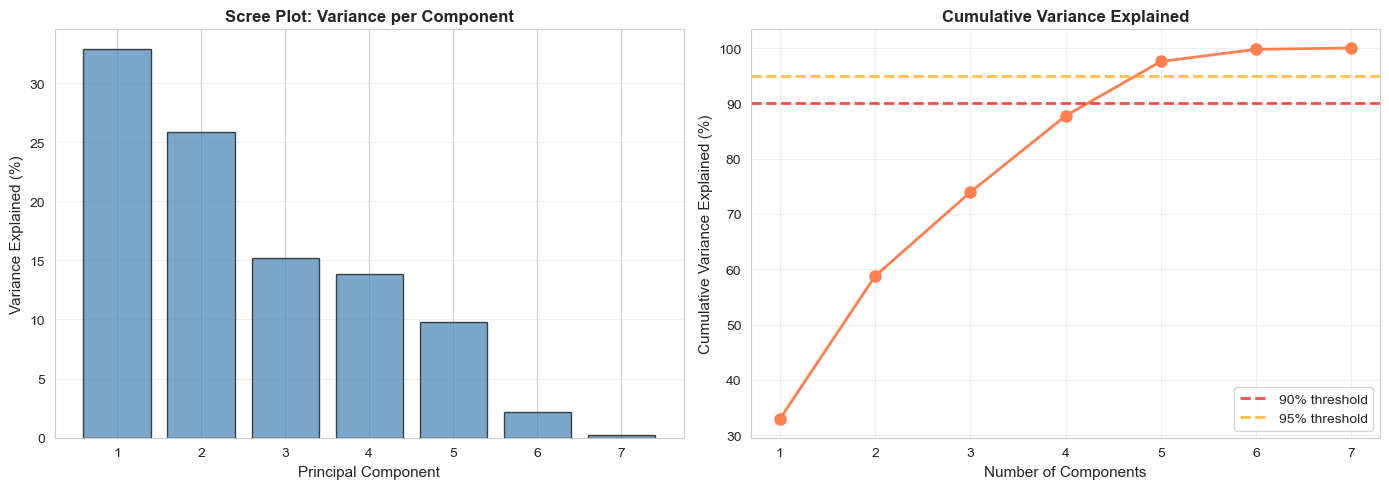


📊 PCA visualization complete!


In [41]:
# Principal Component Analysis to assess effective dimensionality
if len(corr_matrix) > 0 and len(available_vars) > 2:
    
    print("=" * 70)
    print("PRINCIPAL COMPONENT ANALYSIS (PCA):")
    print("=" * 70)
    
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    
    # Prepare data (drop NaNs for PCA)
    weather_data_pca = weather_data.dropna()
    
    if len(weather_data_pca) > 10:
        # Standardize features
        scaler = StandardScaler()
        weather_scaled = scaler.fit_transform(weather_data_pca)
        
        # Fit PCA
        pca = PCA()
        pca.fit(weather_scaled)
        
        # Get explained variance
        explained_var = pca.explained_variance_ratio_
        cumulative_var = np.cumsum(explained_var)
        
        print(f"\nPCA Results (n={len(weather_data_pca)} samples):")
        print("-" * 70)
        print(f"{'Component':<12} {'Variance %':<15} {'Cumulative %':<15}")
        print("-" * 70)
        
        for i in range(len(explained_var)):
            print(f"PC{i+1:<10} {explained_var[i]*100:>10.2f}%     {cumulative_var[i]*100:>10.2f}%")
        
        # Identify how many components needed for 90% variance
        n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
        n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
        
        print("\n" + "=" * 70)
        print("DIMENSIONALITY INSIGHTS:")
        print("=" * 70)
        print(f"  Components for 90% variance: {n_components_90}/{len(available_vars)}")
        print(f"  Components for 95% variance: {n_components_95}/{len(available_vars)}")
        
        # Visualize explained variance
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Scree plot
        ax1.bar(range(1, len(explained_var)+1), explained_var * 100, 
                alpha=0.7, color='steelblue', edgecolor='black')
        ax1.set_xlabel('Principal Component', fontsize=11)
        ax1.set_ylabel('Variance Explained (%)', fontsize=11)
        ax1.set_title('Scree Plot: Variance per Component', fontweight='bold')
        ax1.set_xticks(range(1, len(explained_var)+1))
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Cumulative variance plot
        ax2.plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 
                marker='o', linewidth=2, markersize=8, color='coral')
        ax2.axhline(90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
        ax2.axhline(95, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='95% threshold')
        ax2.set_xlabel('Number of Components', fontsize=11)
        ax2.set_ylabel('Cumulative Variance Explained (%)', fontsize=11)
        ax2.set_title('Cumulative Variance Explained', fontweight='bold')
        ax2.set_xticks(range(1, len(cumulative_var)+1))
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n📊 PCA visualization complete!")
        
    else:
        print("\n⚠️  Insufficient samples for PCA analysis")

In [42]:
# Recommendations for feature selection
print("\n" + "=" * 70)
print("FEATURE SELECTION RECOMMENDATIONS")
print("=" * 70)

if len(corr_matrix) > 0:
    
    # Combine insights from correlation and discriminative power
    recommendations = []
    
    # Get discriminative power info from earlier analysis
    if len(df_comparison) > 0:
        strong_vars = df_comparison[df_comparison['abs_cohens_d'] >= 0.5]['variable'].tolist()
        moderate_vars = df_comparison[(df_comparison['abs_cohens_d'] >= 0.2) & 
                                     (df_comparison['abs_cohens_d'] < 0.5)]['variable'].tolist()
        weak_vars = df_comparison[df_comparison['abs_cohens_d'] < 0.2]['variable'].tolist()
        
        print("\n1. FEATURE IMPORTANCE SUMMARY:")
        print(f"   Strong discriminators (|d| ≥ 0.5):   {len(strong_vars)} vars → {strong_vars}")
        print(f"   Moderate discriminators (|d| ≥ 0.2): {len(moderate_vars)} vars → {moderate_vars}")
        print(f"   Weak discriminators (|d| < 0.2):     {len(weak_vars)} vars → {weak_vars}")
        
        print("\n2. CORRELATION-BASED INSIGHTS:")
        if high_corr_pairs:
            print(f"   Found {len(df_high_corr)} highly correlated pairs")
            print("   → Redundancy detected - can simplify feature set")
            
            # For highly correlated pairs, recommend keeping the stronger discriminator
            for idx, row in df_high_corr.iterrows():
                var1, var2 = row['var1'], row['var2']
                
                # Get discriminative power for each
                if len(df_comparison) > 0:
                    d1 = df_comparison[df_comparison['variable'] == var1]['abs_cohens_d'].values
                    d2 = df_comparison[df_comparison['variable'] == var2]['abs_cohens_d'].values
                    
                    if len(d1) > 0 and len(d2) > 0:
                        if d1[0] > d2[0]:
                            print(f"   • {var1} and {var2} (r={row['correlation']:.2f})")
                            print(f"     → Keep {var1} (stronger discriminator, d={d1[0]:.3f})")
                        else:
                            print(f"   • {var1} and {var2} (r={row['correlation']:.2f})")
                            print(f"     → Keep {var2} (stronger discriminator, d={d2[0]:.3f})")
        else:
            print("   ✓ Low correlation between variables")
            print("   → All features provide independent information")
        
        print("\n3. RECOMMENDED FEATURE SETS:")
        
        # Option 1: All strong + moderate discriminators
        option1 = strong_vars + moderate_vars
        print(f"\n   OPTION 1 - Strong + Moderate ({len(option1)} features):")
        for var in option1:
            d_val = df_comparison[df_comparison['variable'] == var]['cohens_d'].values[0]
            print(f"      ✓ {var:<20} (d={d_val:>6.3f})")
        print(f"   → Balances signal strength with feature completeness")
        
        # Option 2: Only strong discriminators
        if len(strong_vars) > 0:
            print(f"\n   OPTION 2 - Strong Only ({len(strong_vars)} features):")
            for var in strong_vars:
                d_val = df_comparison[df_comparison['variable'] == var]['cohens_d'].values[0]
                print(f"      ✓ {var:<20} (d={d_val:>6.3f})")
            print(f"   → Minimal feature set with maximum signal")
        
        # Option 3: Remove only the weakest
        if len(weak_vars) > 2:
            weakest_vars = df_comparison.nsmallest(2, 'abs_cohens_d')['variable'].tolist()
            option3 = [v for v in available_vars if v not in weakest_vars]
            print(f"\n   OPTION 3 - Remove Weakest ({len(option3)} features):")
            print(f"      Drop: {weakest_vars}")
            print(f"      Keep: {option3}")
            print(f"   → Conservative approach - remove only bottom performers")
        
        print("\n4. FINAL RECOMMENDATION:")
        
        if len(strong_vars) >= 3 and len(df_high_corr) > 0:
            print("   ⭐ START WITH OPTION 2 (Strong discriminators only)")
            print(f"      → {len(strong_vars)} uncorrelated, high-signal features")
            print("      → Reduced complexity for initial CNN training")
            print("      → Add moderate features later if needed")
        elif len(option1) <= 4:
            print("   ⭐ USE OPTION 1 (Strong + Moderate)")
            print(f"      → {len(option1)} features provide good coverage")
            print("      → Not too many features to cause overfitting")
        else:
            print("   ⭐ USE OPTION 3 (Remove weakest only)")
            print("      → Conservative approach for initial experiments")
            print("      → Run ablation study to validate")
        
        print("\n5. IMPLEMENTATION:")
        print("   1. Start with recommended feature set")
        print("   2. Run ablation study: test all combinations")
        print("   3. Monitor for overfitting (train vs. validation loss)")
        print("   4. Consider PCA if model struggles with current features")
    
    else:
        print("\n⚠️  Cannot provide feature recommendations - run Section 9 analysis first")

else:
    print("\n⚠️  Correlation analysis not available")

print("\n" + "=" * 70)


FEATURE SELECTION RECOMMENDATIONS

1. FEATURE IMPORTANCE SUMMARY:
   Strong discriminators (|d| ≥ 0.5):   2 vars → ['v_altse_mean', 'v_ff_mean']
   Moderate discriminators (|d| ≥ 0.2): 1 vars → ['v_ffgust_mean']
   Weak discriminators (|d| < 0.2):     4 vars → ['v_dd_mean', 'v_t_mean', 'v_rh_mean', 'v_td_mean']

2. CORRELATION-BASED INSIGHTS:
   Found 2 highly correlated pairs
   → Redundancy detected - can simplify feature set
   • v_ff_mean and v_ffgust_mean (r=0.84)
     → Keep v_ff_mean (stronger discriminator, d=0.596)
   • v_t_mean and v_td_mean (r=0.71)
     → Keep v_t_mean (stronger discriminator, d=0.166)

3. RECOMMENDED FEATURE SETS:

   OPTION 1 - Strong + Moderate (3 features):
      ✓ v_altse_mean         (d=-1.278)
      ✓ v_ff_mean            (d= 0.596)
      ✓ v_ffgust_mean        (d= 0.452)
   → Balances signal strength with feature completeness

   OPTION 2 - Strong Only (2 features):
      ✓ v_altse_mean         (d=-1.278)
      ✓ v_ff_mean            (d= 0.596)
   

### 9.3 Derived Feature Engineering 🔧

**Goal:** Create meteorologically meaningful features by combining raw MADIS variables.

Even though some individual features are weak or correlated, their **combinations** may capture important physics:

**Features to Engineer:**
1. **Wind Shear Proxy** = Wind Gust - Wind Speed
   - Captures turbulence and atmospheric variability
   - High values indicate chaotic/unstable airflow (tornado-favorable)
   - Alternative to true vertical wind shear (which requires altitude data)

2. **Temperature-Dewpoint Spread** = Temperature - Dewpoint  
   - Classic instability indicator in severe weather
   - Large spread (>10 K) = dry/unstable air = convective potential
   - Small spread (<2 K) = saturated/stable air

**Why This Matters:**
- Raw features are weak individually → but their **differences** may be predictive
- Removes redundancy (temp & dewpoint correlated, wind & gust correlated)
- Physically interpretable (meteorologists use these metrics)

In [ ]:
# Create derived features
print("DERIVED FEATURE ENGINEERING")
print("=" * 70)

# Check if we have the required base features
has_wind_data = 'v_ff_mean' in df_merged.columns and 'v_ffgust_mean' in df_merged.columns
has_temp_data = 'v_t_mean' in df_merged.columns and 'v_td_mean' in df_merged.columns

if has_wind_data or has_temp_data:
    
    print("\nCreating derived features from MADIS variables...")
    
    derived_features = []
    
    # 1. Wind Shear Proxy (turbulence indicator)
    if has_wind_data:
        df_merged['wind_shear_proxy'] = df_merged['v_ffgust_mean'] - df_merged['v_ff_mean']
        derived_features.append('wind_shear_proxy')
        
        n_valid = df_merged['wind_shear_proxy'].notna().sum()
        print(f"\n✓ Wind Shear Proxy created")
        print(f"  Formula: Gust - Sustained Wind Speed")
        print(f"  Valid samples: {n_valid}")
        print(f"  Range: {df_merged['wind_shear_proxy'].min():.2f} to {df_merged['wind_shear_proxy'].max():.2f} m/s")
        print(f"  Mean: {df_merged['wind_shear_proxy'].mean():.2f} m/s")
    
    # 2. Temperature-Dewpoint Spread (instability indicator)  
    if has_temp_data:
        df_merged['temp_dewpoint_spread'] = df_merged['v_t_mean'] - df_merged['v_td_mean']
        derived_features.append('temp_dewpoint_spread')
        
        n_valid = df_merged['temp_dewpoint_spread'].notna().sum()
        print(f"\n✓ Temperature-Dewpoint Spread created")
        print(f"  Formula: Temperature - Dewpoint Temperature")
        print(f"  Valid samples: {n_valid}")
        print(f"  Range: {df_merged['temp_dewpoint_spread'].min():.2f} to {df_merged['temp_dewpoint_spread'].max():.2f} K")
        print(f"  Mean: {df_merged['temp_dewpoint_spread'].mean():.2f} K")
    
    print(f"\n{'='*70}")
    print(f"Created {len(derived_features)} derived features:")
    for feat in derived_features:
        print(f"  • {feat}")
    
else:
    print("\n⚠️  Cannot create derived features - missing base variables")
    derived_features = []

In [ ]:
# Test discriminative power of derived features
if len(derived_features) > 0 and 'ef_number' in df_merged.columns:
    
    print("\n" + "=" * 70)
    print("DISCRIMINATIVE POWER ANALYSIS - DERIVED FEATURES")
    print("=" * 70)
    
    from scipy import stats
    
    # Separate tornado vs non-tornado
    df_tornado_derived = df_merged[df_merged['ef_number'] >= 0].copy()
    df_non_tornado_derived = df_merged[df_merged['ef_number'] < 0].copy()
    
    derived_comparison = []
    
    for feature in derived_features:
        tornado_vals = df_tornado_derived[feature].dropna()
        non_tornado_vals = df_non_tornado_derived[feature].dropna()
        
        if len(tornado_vals) > 0 and len(non_tornado_vals) > 0:
            # T-test
            t_stat, p_value = stats.ttest_ind(tornado_vals, non_tornado_vals)
            
            # Cohen's d
            pooled_std = np.sqrt((tornado_vals.std()**2 + non_tornado_vals.std()**2) / 2)
            cohens_d = (tornado_vals.mean() - non_tornado_vals.mean()) / pooled_std if pooled_std > 0 else 0
            
            derived_comparison.append({
                'feature': feature,
                'tornado_mean': tornado_vals.mean(),
                'tornado_std': tornado_vals.std(),
                'non_tornado_mean': non_tornado_vals.mean(),
                'non_tornado_std': non_tornado_vals.std(),
                'cohens_d': cohens_d,
                'abs_cohens_d': abs(cohens_d),
                'p_value': p_value
            })
    
    df_derived_comp = pd.DataFrame(derived_comparison)
    
    print("\nStatistical Comparison: Tornado vs Non-Tornado")
    print("-" * 70)
    
    for idx, row in df_derived_comp.iterrows():
        sig_marker = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else "ns"
        
        # Determine strength
        if row['abs_cohens_d'] >= 0.8:
            strength = "LARGE"
        elif row['abs_cohens_d'] >= 0.5:
            strength = "MEDIUM"
        elif row['abs_cohens_d'] >= 0.2:
            strength = "SMALL"
        else:
            strength = "NEGLIGIBLE"
        
        print(f"\n{row['feature']}:")
        print(f"  Tornado:     {row['tornado_mean']:>10.3f} ± {row['tornado_std']:.3f}")
        print(f"  Non-tornado: {row['non_tornado_mean']:>10.3f} ± {row['non_tornado_std']:.3f}")
        print(f"  Cohen's d:   {row['cohens_d']:>10.3f}  ({strength} effect)")
        print(f"  p-value:     {row['p_value']:>10.4f} {sig_marker}")
    
    # Compare to base features
    print("\n" + "=" * 70)
    print("COMPARISON TO BASE FEATURES:")
    print("=" * 70)
    
    if len(df_comparison) > 0:
        # For wind shear proxy vs base wind features
        if 'wind_shear_proxy' in derived_features:
            wind_shear_d = df_derived_comp[df_derived_comp['feature'] == 'wind_shear_proxy']['abs_cohens_d'].values[0]
            wind_d = df_comparison[df_comparison['variable'] == 'v_ff_mean']['abs_cohens_d'].values[0] if 'v_ff_mean' in df_comparison['variable'].values else 0
            gust_d = df_comparison[df_comparison['variable'] == 'v_ffgust_mean']['abs_cohens_d'].values[0] if 'v_ffgust_mean' in df_comparison['variable'].values else 0
            
            print(f"\nWind Features:")
            print(f"  Wind Speed (base):        |d| = {wind_d:.3f}")
            print(f"  Wind Gust (base):         |d| = {gust_d:.3f}")
            print(f"  Wind Shear Proxy (NEW):   |d| = {wind_shear_d:.3f}")
            
            if wind_shear_d > max(wind_d, gust_d):
                print(f"  ✓ SHEAR PROXY IS STRONGER than both base features!")
                print(f"    → Consider using this instead of separate wind/gust")
            elif wind_shear_d > min(wind_d, gust_d):
                print(f"  ⚡ Shear proxy is moderately strong")
                print(f"    → Could supplement stronger base feature")
            else:
                print(f"  ⚠️  Shear proxy is weaker than base features")
                print(f"    → Base features may be sufficient")
        
        # For temp-dewpoint spread vs base temp features
        if 'temp_dewpoint_spread' in derived_features:
            spread_d = df_derived_comp[df_derived_comp['feature'] == 'temp_dewpoint_spread']['abs_cohens_d'].values[0]
            temp_d = df_comparison[df_comparison['variable'] == 'v_t_mean']['abs_cohens_d'].values[0] if 'v_t_mean' in df_comparison['variable'].values else 0
            dewpoint_d = df_comparison[df_comparison['variable'] == 'v_td_mean']['abs_cohens_d'].values[0] if 'v_td_mean' in df_comparison['variable'].values else 0
            
            print(f"\nTemperature Features:")
            print(f"  Temperature (base):       |d| = {temp_d:.3f}")
            print(f"  Dewpoint (base):          |d| = {dewpoint_d:.3f}")
            print(f"  Temp-Dewpoint Spread (NEW): |d| = {spread_d:.3f}")
            
            if spread_d > max(temp_d, dewpoint_d):
                print(f"  ✓ SPREAD IS STRONGER than both base features!")
                print(f"    → Use this instead of separate temp/dewpoint")
            elif spread_d > min(temp_d, dewpoint_d):
                print(f"  ⚡ Spread is moderately strong")
                print(f"    → Could supplement stronger base feature")
            else:
                print(f"  ⚠️  Spread is weaker than base features")
                print(f"    → Base features may be sufficient")

else:
    print("\nCannot test derived features - missing required data")
    df_derived_comp = pd.DataFrame()

In [ ]:
# Check correlation of derived features with base features
if len(derived_features) > 0:
    
    print("\n" + "=" * 70)
    print("CORRELATION CHECK - DERIVED vs BASE FEATURES")
    print("=" * 70)
    print("\nChecking if derived features are independent from base features...")
    
    for derived_feat in derived_features:
        print(f"\n{derived_feat}:")
        print("-" * 70)
        
        # Calculate correlation with all base features
        correlations = []
        for base_feat in available_vars:
            valid_data = df_merged[[derived_feat, base_feat]].dropna()
            if len(valid_data) > 10:
                corr = valid_data[derived_feat].corr(valid_data[base_feat])
                correlations.append({
                    'base_feature': base_feat,
                    'correlation': corr,
                    'abs_correlation': abs(corr)
                })
        
        df_corr_check = pd.DataFrame(correlations)
        df_corr_check = df_corr_check.sort_values('abs_correlation', ascending=False)
        
        # Display top correlations
        for idx, row in df_corr_check.head(5).iterrows():
            if row['abs_correlation'] > 0.7:
                marker = "⚠️  HIGH CORRELATION"
            elif row['abs_correlation'] > 0.5:
                marker = "⚡ MODERATE"
            else:
                marker = "✓ LOW"
            
            print(f"  {row['base_feature']:<20} r = {row['correlation']:>6.3f}  {marker}")
        
        # Verdict
        max_corr = df_corr_check['abs_correlation'].max()
        if max_corr < 0.7:
            print(f"\n  ✓ INDEPENDENT: Max correlation = {max_corr:.3f}")
            print(f"    → Provides new information beyond base features")
        else:
            print(f"\n  ⚠️  DEPENDENT: Max correlation = {max_corr:.3f}")
            print(f"    → Largely redundant with base features")

In [ ]:
# Final recommendations for derived features
print("\n" + "=" * 70)
print("DERIVED FEATURE RECOMMENDATIONS")
print("=" * 70)

if len(df_derived_comp) > 0:
    
    # Rank derived features
    df_derived_comp_sorted = df_derived_comp.sort_values('abs_cohens_d', ascending=False)
    
    print("\nDerived Feature Ranking:")
    print("-" * 70)
    for idx, row in df_derived_comp_sorted.iterrows():
        strength = "★★★ STRONG" if row['abs_cohens_d'] >= 0.5 else "★★ MODERATE" if row['abs_cohens_d'] >= 0.2 else "★ WEAK"
        print(f"  {row['feature']:<30} |d| = {row['abs_cohens_d']:.3f}  {strength}")
    
    print("\n" + "=" * 70)
    print("FINAL RECOMMENDATIONS:")
    print("=" * 70)
    
    # Specific recommendations for each feature
    for feature in derived_features:
        feat_data = df_derived_comp[df_derived_comp['feature'] == feature].iloc[0]
        
        print(f"\n{feature}:")
        
        if feat_data['abs_cohens_d'] >= 0.5:
            print(f"  ✓ INCLUDE IN CNN MODEL")
            print(f"    → Strong discriminative power (|d| = {feat_data['abs_cohens_d']:.3f})")
            
            # Check if it replaces base features
            if feature == 'wind_shear_proxy':
                if 'v_ff_mean' in df_comparison['variable'].values and 'v_ffgust_mean' in df_comparison['variable'].values:
                    print(f"    → Can REPLACE v_ff_mean and v_ffgust_mean")
                    print(f"    → Reduces 2 features to 1 without losing signal")
            
            elif feature == 'temp_dewpoint_spread':
                if 'v_t_mean' in df_comparison['variable'].values and 'v_td_mean' in df_comparison['variable'].values:
                    print(f"    → Can REPLACE v_t_mean and v_td_mean")
                    print(f"    → More physically meaningful than raw values")
        
        elif feat_data['abs_cohens_d'] >= 0.2:
            print(f"  ⚡ CONSIDER INCLUDING")
            print(f"    → Moderate signal (|d| = {feat_data['abs_cohens_d']:.3f})")
            print(f"    → Test in ablation study")
        
        else:
            print(f"  ⚠️  SKIP")
            print(f"    → Weak signal (|d| = {feat_data['abs_cohens_d']:.3f})")
            print(f"    → Unlikely to improve model performance")
    
    # Updated feature set recommendation
    print("\n" + "=" * 70)
    print("UPDATED FEATURE SET WITH DERIVED FEATURES:")
    print("=" * 70)
    
    # Combine strong base features with strong derived features
    strong_base = df_comparison[df_comparison['abs_cohens_d'] >= 0.5]['variable'].tolist() if len(df_comparison) > 0 else []
    strong_derived = df_derived_comp[df_derived_comp['abs_cohens_d'] >= 0.5]['feature'].tolist()
    
    print(f"\nRecommended Feature Set:")
    
    # Remove redundant base features if derived ones replace them
    final_features = strong_base.copy()
    
    if 'wind_shear_proxy' in strong_derived:
        # Remove base wind features if shear proxy is strong
        final_features = [f for f in final_features if f not in ['v_ff_mean', 'v_ffgust_mean']]
        final_features.append('wind_shear_proxy')
        print(f"  • wind_shear_proxy (replaces v_ff_mean + v_ffgust_mean)")
    
    if 'temp_dewpoint_spread' in strong_derived:
        # Remove base temp features if spread is strong
        final_features = [f for f in final_features if f not in ['v_t_mean', 'v_td_mean']]
        final_features.append('temp_dewpoint_spread')
        print(f"  • temp_dewpoint_spread (replaces v_t_mean + v_td_mean)")
    
    # Add remaining strong base features
    for feat in final_features:
        if feat not in strong_derived:
            print(f"  • {feat}")
    
    print(f"\n  Total features: {len(final_features)}")
    print(f"  → Simplified from {len(available_vars)} base features")
    print(f"  → More physically interpretable")
    print(f"  → Reduced multicollinearity")

else:
    print("\n⚠️  Analysis incomplete - cannot provide recommendations")

print("\n" + "=" * 70)

## 10. Prepare Final Dataset for CNN

Create clean, standardized features ready for CNN integration.

In [43]:
# Define standard feature set for CNN
# Using mean values of key weather variables
standard_features = {
    'v_t_mean': 'temperature',           # Temperature (Kelvin)
    'v_td_mean': 'dewpoint',             # Dew point temperature (Kelvin)
    'v_rh_mean': 'relative_humidity',    # Relative humidity (%)
    'v_ff_mean': 'wind_speed',           # Wind speed (m/s)
    'v_dd_mean': 'wind_direction',       # Wind direction (degrees)
    'v_altse_mean': 'pressure',          # Atmospheric pressure (Pa)
    'v_ffgust_mean': 'wind_gust'         # Wind gust speed (m/s)
}

# Select and rename features
available_features = {k: v for k, v in standard_features.items() if k in df_merged.columns}
print(f"Available MADIS features: {len(available_features)}")
for old_name, new_name in available_features.items():
    print(f"  - {old_name} → {new_name}")

# Create final dataset - select columns that exist
base_cols = ['storm_id', 'event_id', 'timestamp']
optional_cols = ['type', 'ef_number', 'category']
final_cols = base_cols + [col for col in optional_cols if col in df_merged.columns] + list(available_features.keys())

df_final = df_merged[final_cols].copy()

# Rename columns
df_final.rename(columns=available_features, inplace=True)

# Add metadata
df_final['has_madis_data'] = True
df_final['num_stations'] = df_merged['total_stations']
df_final['num_observations'] = df_merged['total_observations']

print(f"\nFinal dataset shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")

# Check for missing values
print("\nMissing values:")
missing = df_final.isnull().sum()
print(missing[missing > 0])

df_final.head(10)

Available MADIS features: 7
  - v_t_mean → temperature
  - v_td_mean → dewpoint
  - v_rh_mean → relative_humidity
  - v_ff_mean → wind_speed
  - v_dd_mean → wind_direction
  - v_altse_mean → pressure
  - v_ffgust_mean → wind_gust

Final dataset shape: (18026, 16)
Columns: ['storm_id', 'event_id', 'timestamp', 'type', 'ef_number', 'category', 'temperature', 'dewpoint', 'relative_humidity', 'wind_speed', 'wind_direction', 'pressure', 'wind_gust', 'has_madis_data', 'num_stations', 'num_observations']

Missing values:
event_id              557
type                  557
ef_number             557
category              557
temperature           385
dewpoint              528
relative_humidity     528
wind_speed            360
wind_direction        360
pressure             2972
wind_gust             457
dtype: int64


,storm_id,event_id,timestamp,type,ef_number,category,temperature,dewpoint,relative_humidity,wind_speed,wind_direction,pressure,wind_gust,has_madis_data,num_stations,num_observations
0,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
1,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
2,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
3,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
4,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
5,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
6,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
7,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
8,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7
9,478457,478457,2013-09-12 02:10:00,train,-1.0,NUL,294.261108,293.255554,94.0,1.34112,20.0,101410.0,2.2352,True,1,7


In [44]:
# Basic statistics for final features
print("Final Weather Feature Statistics:")
print("="*70)
weather_cols = list(available_features.values())
if weather_cols:
    print(df_final[weather_cols].describe().round(2))

Final Weather Feature Statistics:
       temperature  dewpoint  relative_humidity  wind_speed  wind_direction  \
count     17641.00  17498.00           17498.00    17666.00        17666.00   
mean        294.27    290.82              82.08        1.62          186.31   
std           5.70      4.77              15.92        1.57           75.01   
min         275.93    272.97              17.00        0.00            0.00   
25%         290.93    288.62              73.50        0.45          139.00   
50%         294.82    291.41              89.00        1.34          187.00   
75%         298.15    294.09              94.00        2.24          236.00   
max         308.71    299.41             100.00       12.29          360.00   

        pressure  wind_gust  
count   15054.00   17569.00  
mean   100835.57       4.31  
std       521.33       3.34  
min     98855.00       0.00  
25%    100475.00       1.79  
50%    100890.00       4.02  
75%    101250.00       6.26  
max    102090.

## 11. Save Cleaned Dataset

In [45]:
# Save to CSV
output_file = data_root / 'madis_features_clean.csv'
df_final.to_csv(output_file, index=False)
print(f"Saved cleaned MADIS features to: {output_file}")
print(f"  - {len(df_final)} storms")
print(f"  - {len(df_final.columns)} columns")

# Also save mapping of storm_id to features as pickle for faster loading
import pickle
output_pickle = data_root / 'madis_features_clean.pkl'
df_final.to_pickle(output_pickle)
print(f"\nAlso saved as pickle: {output_pickle}")

# Create a summary report
summary = {
    'total_storms_with_madis': len(df_final),
    'total_weather_observations': df_final['num_observations'].sum(),
    'avg_stations_per_storm': df_final['num_stations'].mean(),
    'features_available': list(available_features.values()),
}

if 'category' in df_final.columns:
    summary['coverage_by_category'] = df_final.groupby('category').size().to_dict()
    
if 'ef_number' in df_final.columns:
    summary['ef_ratings_covered'] = sorted(df_final['ef_number'].dropna().unique().tolist())

print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)
for key, value in summary.items():
    print(f"{key}: {value}")

Saved cleaned MADIS features to: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/madis_features_clean.csv
  - 18026 storms
  - 16 columns

Also saved as pickle: /Users/evanshabsove/Documents/tornado_reserch_paper/tornet/tornet_data/madis_features_clean.pkl

SUMMARY REPORT
total_storms_with_madis: 18026
total_weather_observations: 250326
avg_stations_per_storm: 2.163763452790414
features_available: ['temperature', 'dewpoint', 'relative_humidity', 'wind_speed', 'wind_direction', 'pressure', 'wind_gust']
coverage_by_category: {'NUL': 12589, 'TOR': 363, 'WRN': 4517}
ef_ratings_covered: [-1.0, 0.0, 1.0, 2.0, 3.0]


## 12. Next Steps for CNN Integration

The cleaned MADIS data is now ready to be integrated into your CNN model. Here's how to use it:

### Option 1: Hybrid CNN Architecture (Recommended)
```python
# Pseudocode for model architecture
radar_input = Input(shape=(height, width, channels))  # Radar data
madis_input = Input(shape=(7,))  # 7 MADIS features

# CNN branch for radar
cnn_branch = Conv2D(...)(radar_input)
cnn_branch = MaxPooling2D(...)(cnn_branch)
...
cnn_flat = Flatten()(cnn_branch)

# Dense branch for MADIS features
madis_branch = Dense(64, activation='relu')(madis_input)
madis_branch = Dropout(0.3)(madis_branch)
madis_branch = Dense(32, activation='relu')(madis_branch)

# Concatenate
combined = Concatenate()([cnn_flat, madis_branch])
output = Dense(1, activation='sigmoid')(combined)
```

### Option 2: Handle Missing Data
For storms without MADIS data, you can:
- Use mean imputation
- Use a separate "has_data" indicator feature
- Train model to handle missing values gracefully

### Data Files Created:
- `madis_features_clean.csv` - Human-readable CSV
- `madis_features_clean.pkl` - Fast-loading pickle file
- `madis_data_problematic/` - Moved problematic files for inspection